Can you predict how capable each applicant is of repaying a loan?

# 1. Problem Definition

Many people struggle to access loans because they have insufficient or non-existent credit histories. This can make it difficult for financial institutions to accurately assess their ability to repay a loan and may leave underserved customers vulnerable to untrustworthy lenders.

Home Credit aims to improve financial inclusion by providing a positive and safe borrowing experience to people who may have limited traditional credit histories. To achieve this, Home Credit uses alternative sources of information, including transactional and other financial data, to better understand a client's repayment ability.

The goal of this project is to develop a machine learning classification model that can predict whether a loan applicant is likely to experience repayment difficulties.

More specifically, given information about a loan application and the applicant's previous financial and repayment history, the model will estimate the probability that the applicant will default or experience difficulty repaying the loan.

The target variable is `TARGET`:

* `0` — the applicant did not experience repayment difficulties.
* `1` — the applicant experienced repayment difficulties.

This is therefore a **binary classification problem**.

The ultimate objective is to use data-driven predictions to help distinguish applicants who are likely to repay from those who may experience repayment difficulties, while supporting Home Credit's broader goal of responsible financial inclusion.


# 2. Evaluation

Because this is a binary classification problem, the model should be evaluated using metrics that measure how well it distinguishes between applicants who experience repayment difficulties and those who do not.

The primary evaluation metric will be **ROC-AUC (Receiver Operating Characteristic Area Under the Curve)**.

ROC-AUC measures how well the model ranks applicants with repayment difficulties above applicants who are able to repay. A value closer to 1 indicates better discrimination, while a value around 0.5 indicates performance similar to random classification.

In addition to ROC-AUC, I will evaluate the model using:

* **Precision** — the proportion of applicants predicted to have repayment difficulties who actually experience them.
* **Recall** — the proportion of applicants who experience repayment difficulties that the model correctly identifies.
* **F1-score** — the harmonic mean of precision and recall.
* **Confusion matrix** — to examine true positives, true negatives, false positives, and false negatives.

The validation data will be kept separate from the training data so that the model can be evaluated on observations it has not seen during training.

Since credit-risk datasets are often imbalanced, accuracy alone will not be considered a sufficient evaluation metric.


## Features

The dataset contains information from several related tables. The main application table contains information about the current loan application, while the other tables contain historical information about the applicant's previous credit and repayment behaviour.

The main feature groups will include:

### Application Features

Features from `application_train.csv` and `application_test.csv`, including:

* Applicant income
* Loan amount
* Annuity amount
* Applicant age
* Employment duration
* Family information
* Housing information
* Education level
* Occupation
* Income type
* Credit-to-income relationships

### Previous Credit Features

Information from `bureau.csv` and `bureau_balance.csv` will be aggregated to the current applicant level.

Possible features include:

* Number of previous credits
* Total previous credit amount
* Average previous credit amount
* Number of active credits
* Number of closed credits
* Credit utilisation-related measures
* Previous credit history length

### Previous Application Features

Information from `previous_application.csv` can be used to create features such as:

* Number of previous applications
* Number of approved applications
* Number of refused applications
* Previous loan amounts
* Average previous loan amount
* Previous application status

### Repayment Features

`installments_payments.csv` contains historical repayment information. It can be transformed into features such as:

* Number of previous installments
* Number of late payments
* Average payment delay
* Maximum payment delay
* Total amount paid
* Difference between installments and actual payments

### POS and Credit Card Features

`POS_CASH_balance.csv` and `credit_card_balance.csv` provide historical information about previous POS, cash, and credit-card accounts.

These tables can be aggregated to create features such as:

* Number of previous accounts
* Average outstanding balance
* Maximum outstanding balance
* Number of delinquent accounts
* Credit utilization measures
* Previous account status

### Feature Engineering

Because several of these datasets contain multiple rows for the same applicant, the historical information will be aggregated using `SK_ID_CURR` so that the final modelling dataset contains one row per current loan application.

Categorical variables will be encoded into numerical representations, while missing numerical values will be handled using appropriate imputation techniques.

Feature engineering will be performed carefully to avoid **data leakage**. Only information that would have been available at the time of the current loan application should be used to predict repayment difficulties.


## Modelling and Experimentation

The modelling process will begin with a simple baseline model and progressively move toward more sophisticated machine learning algorithms.

First, the processed dataset will be divided into training and validation sets. The training set will be used to fit the models, while the validation set will be used to evaluate their performance on unseen data.

The initial baseline will use a simple classification model such as **Logistic Regression**. This will provide a reference point against which more complex models can be compared.

The following models can then be experimented with:

1. **Logistic Regression** — provides a simple and interpretable baseline.
2. **Random Forest Classifier** — captures nonlinear relationships and interactions between features.
3. **Gradient Boosting models** — can capture more complex patterns in the data and are commonly effective for tabular datasets.
4. **LightGBM / XGBoost** — will be considered for further experimentation with the large, structured dataset.

For each model, I will compare performance using ROC-AUC as the primary evaluation metric, together with precision, recall, F1-score, and the confusion matrix.

The experimentation process will involve:

* Establishing a baseline model.
* Training different machine learning algorithms.
* Comparing their validation performance.
* Performing hyperparameter tuning on promising models.
* Examining feature importance where appropriate.
* Checking for overfitting by comparing training and validation performance.
* Selecting a final model based on validation performance and practical considerations.

Cross-validation may also be used during model development to obtain a more reliable estimate of model performance.

Finally, after the model and feature-engineering pipeline have been selected, the final model can be trained using the available labelled training data and used to generate predictions for `application_test.csv`.


### Preparing the tools

we're going to use pandas, matplotlib and Numpy for data analysis and manipulation


In [1]:
# Import all the tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# we want our plots to be inside the notebook
%matplotlib inline

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# LightGBM Classifier
from lightgbm import LGBMClassifier

# XGBoost Classifier
from xgboost import XGBClassifier

# 3. Load Data

In [2]:
df = pd.read_csv("/content/application_train.csv")
df.shape # (arows, columns)

(307511, 122)

# 4. Data Exploration ( exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter expert on the dataset we're working with

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [5]:
# let's find out how many of each class are there
df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


<Axes: xlabel='TARGET'>

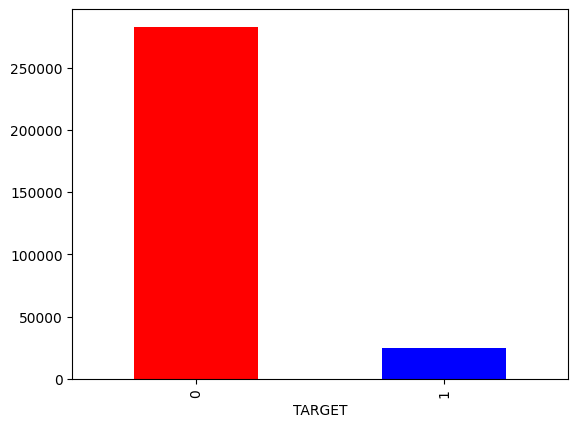

In [6]:
df["TARGET"].value_counts().plot(kind="bar", color=["red","blue"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [8]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [10]:
df.CODE_GENDER.value_counts()

,count
CODE_GENDER,
F,202448
M,105059
XNA,4


In [11]:
# compare target column with CODE_GENDER
pd.crosstab(df.TARGET, df.CODE_GENDER)

CODE_GENDER,F,M,XNA
TARGET,,,
0,188278,94404,4
1,14170,10655,0


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

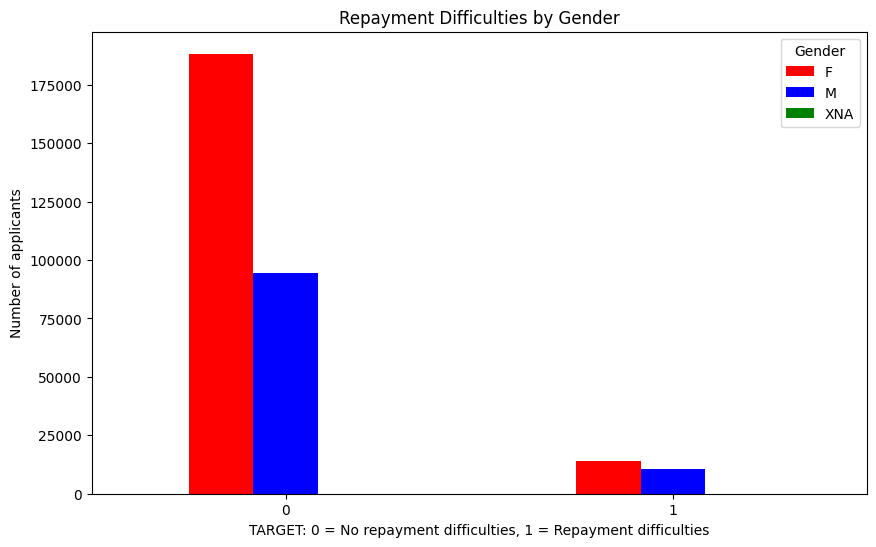

In [12]:
# create a plot of crosstab
pd.crosstab(df.TARGET, df.CODE_GENDER).plot(kind="bar",
                                            figsize=(10, 6),
                                            color=["red", "blue", "green"])
plt.title("Repayment Difficulties by Gender")
plt.xlabel("TARGET: 0 = No repayment difficulties, 1 = Repayment difficulties")
plt.ylabel("Number of applicants")
plt.legend(title="Gender")
plt.xticks(rotation=0)

### Income VS. TARGET

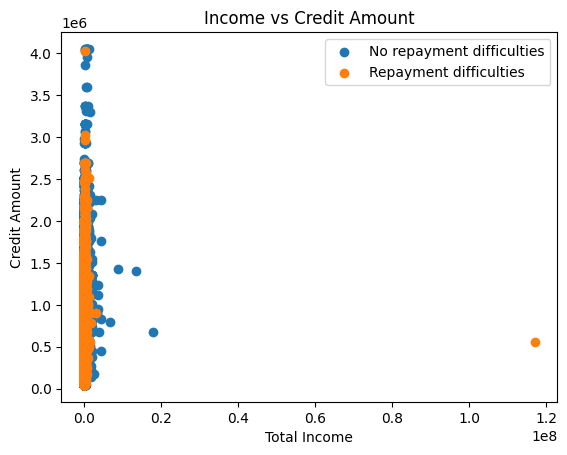

In [13]:
# Relationship between income + repayment difficulty
plt.scatter(
    df.AMT_INCOME_TOTAL[df.TARGET == 0],
    df.AMT_CREDIT[df.TARGET == 0],
    label="No repayment difficulties"
)

plt.scatter(
    df.AMT_INCOME_TOTAL[df.TARGET == 1],
    df.AMT_CREDIT[df.TARGET == 1],
    label="Repayment difficulties"
)

plt.xlabel("Total Income")
plt.ylabel("Credit Amount")
plt.title("Income vs Credit Amount")
plt.legend()
plt.show()

In [14]:
# Are there any missing values?
df.isna().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [15]:
df.dtypes

,0
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
...,...
AMT_REQ_CREDIT_BUREAU_DAY,float64
AMT_REQ_CREDIT_BUREAU_WEEK,float64
AMT_REQ_CREDIT_BUREAU_MON,float64
AMT_REQ_CREDIT_BUREAU_QRT,float64


In [16]:
# Find numeric columns
numeric_columns = df.select_dtypes(include=["number"]).columns

numeric_columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

In [17]:
# Find categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [18]:
# This tells you how many unique categories each column has.
df[categorical_columns].nunique().sort_values()

,0
NAME_CONTRACT_TYPE,2
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
EMERGENCYSTATE_MODE,2
HOUSETYPE_MODE,3
CODE_GENDER,3
FONDKAPREMONT_MODE,4
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6


# 5. Feature Engineering

### Application Features
- annuity_income_ratio
- credit_income_ratio
- credit_goods_ratio
- age_years
- employment_missing
- employment_years
- registration_years
- id_publish_years
- phone_change_years
- income_per_person

In [19]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [20]:
df["annuity_income_ratio"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["annuity_income_ratio"]

,annuity_income_ratio
0,0.121978
1,0.132217
2,0.100000
3,0.219900
4,0.179963
...,...
307506,0.174971
307507,0.166687
307508,0.195941
307509,0.118158


In [21]:
df["annuity_income_ratio"].describe()

,annuity_income_ratio
count,307499.000000
mean,0.180930
std,0.094574
min,0.000224
25%,0.114782
50%,0.162833
75%,0.229067
max,1.875965


In [22]:
df["annuity_income_ratio"].isna().sum()

np.int64(12)

In [23]:
df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["credit_income_ratio"]

,credit_income_ratio
0,2.007889
1,4.790750
2,2.000000
3,2.316167
4,4.222222
...,...
307506,1.617143
307507,3.743750
307508,4.429176
307509,2.164368


In [24]:
df["credit_income_ratio"].isna().sum()

np.int64(0)

In [25]:
df["credit_goods_ratio"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
df["credit_goods_ratio"]

,credit_goods_ratio
0,1.158397
1,1.145199
2,1.000000
3,1.052803
4,1.000000
...,...
307506,1.132000
307507,1.198000
307508,1.158400
307509,1.158394


In [26]:
df["credit_goods_ratio"].describe()

,credit_goods_ratio
count,307233.000000
mean,1.122995
std,0.124045
min,0.150000
25%,1.000000
50%,1.118800
75%,1.198000
max,6.000000


In [27]:
df["credit_goods_ratio"].isna().sum()

np.int64(278)

In [28]:
df["age_years"] = -df["DAYS_BIRTH"] / 365
df["age_years"]

,age_years
0,25.920548
1,45.931507
2,52.180822
3,52.068493
4,54.608219
...,...
307506,25.553425
307507,56.917808
307508,41.002740
307509,32.769863


In [29]:
df["age_years"].describe()

,age_years
count,307511.000000
mean,43.936973
std,11.956133
min,20.517808
25%,34.008219
50%,43.150685
75%,53.923288
max,69.120548


In [30]:
df["age_years"].isna().sum()

np.int64(0)

In [31]:
df["DAYS_EMPLOYED"].describe()

,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000


`365243` is a special value in this dataset, not a normal number of employment days.

In [32]:
df["DAYS_EMPLOYED"].isna().sum()

np.int64(0)

In [33]:
df["DAYS_EMPLOYED"].head(20)

,DAYS_EMPLOYED
0,-637
1,-1188
2,-225
3,-3039
4,-3038
5,-1588
6,-3130
7,-449
8,365243
9,-2019


In [34]:
# Check how many applicants have the special value
(df["DAYS_EMPLOYED"] == 365243).sum()

np.int64(55374)

In [35]:
# Check what percentage of applicants have the special value
(df["DAYS_EMPLOYED"] == 365243).mean() * 100

np.float64(18.00716071945394)

55,374 applicants — about 18% of the entire dataset — have `DAYS_EMPLOYED = 365243`.

We have:

DAYS_EMPLOYED

│

├── negative values → normal employment duration

│

└── 365243 → special value

And because:

365243 / 365 ≈ 1001 years

we know `365243` cannot literally mean 1,001 years of employment.

In the Home Credit dataset, this value is used as a special placeholder for applicants whose employment information is effectively **not available / not employed**, commonly interpreted as unemployed. But importantly, we should treat it as a **special/missing-like category**, rather than pretending it is a real duration.

In [36]:
# Create an indicator:
# 1 = employment value was the special value
# 0 = normal employment value
df["employment_missing"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)


In [37]:
# Check the number of applicants in each group
df["employment_missing"].value_counts()

,count
employment_missing,
0,252137
1,55374


Replace `365243` with `NaN`

Then:

In [38]:
# Replace the special value with NaN
# This prevents 365243 from being treated as a real employment duration
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243,np.nan)

In [39]:
# Inspect the cleaned column
df["DAYS_EMPLOYED"]

,DAYS_EMPLOYED
0,-637.0
1,-1188.0
2,-225.0
3,-3039.0
4,-3038.0
...,...
307506,-236.0
307507,NaN
307508,-7921.0
307509,-4786.0


Create employment duration in years

Now we can safely transform the normal negative day values into positive years.

In [40]:
# Convert employment duration from negative days to years
df["employment_years"] = -df["DAYS_EMPLOYED"] / 365

# Inspect the new feature
df["employment_years"]

,employment_years
0,1.745205
1,3.254795
2,0.616438
3,8.326027
4,8.323288
...,...
307506,0.646575
307507,NaN
307508,21.701370
307509,13.112329


Validate the missing values

Now we make sure our two features agree.

In [41]:
# Check how many applicants are marked as having missing employment information
df["employment_missing"].value_counts()

,count
employment_missing,
0,252137
1,55374


In [42]:
# Check the number of missing employment years
df["employment_years"].isna().sum()

np.int64(55374)

In [43]:
# Check which employment duration values are missing
df["DAYS_EMPLOYED"].isna().sum()

np.int64(55374)

In [44]:
# Compare the indicator with whether DAYS_EMPLOYED is actually missing
pd.crosstab(
    df["employment_missing"],
    df["DAYS_EMPLOYED"].isna()
)

DAYS_EMPLOYED,False,True
employment_missing,,
0,252137,0
1,0,55374


In [45]:
# Understand the distribution of DAYS_REGISTRATION
df["DAYS_REGISTRATION"].describe()

,DAYS_REGISTRATION
count,307511.000000
mean,-4986.120328
std,3522.886321
min,-24672.000000
25%,-7479.500000
50%,-4504.000000
75%,-2010.000000
max,0.000000


In [46]:
# Look at some actual values
df["DAYS_REGISTRATION"].head(20)

,DAYS_REGISTRATION
0,-3648.0
1,-1186.0
2,-4260.0
3,-9833.0
4,-4311.0
5,-4970.0
6,-1213.0
7,-4597.0
8,-7427.0
9,-14437.0


In [47]:
# Check whether there are missing values
df["DAYS_REGISTRATION"].isna().sum()

np.int64(0)

Create registration_years

In [48]:
# Convert registration time from negative days to positive years
df["registration_years"] = -df["DAYS_REGISTRATION"] / 365

# Inspect the new feature
df["registration_years"].head(20)

,registration_years
0,9.994521
1,3.249315
2,11.671233
3,26.939726
4,11.810959
5,13.616438
6,3.323288
7,12.594521
8,20.347945
9,39.553425


In [49]:
# Check the new feature
df["registration_years"].describe()

,registration_years
count,307511.000000
mean,13.660604
std,9.651743
min,-0.000000
25%,5.506849
50%,12.339726
75%,20.491781
max,67.594521


In [50]:
# Check for missing values in the new feature
df["registration_years"].isna().sum()

np.int64(0)

In [51]:
# Compare the original and transformed values
df[["DAYS_REGISTRATION", "registration_years"]].head(10)

,DAYS_REGISTRATION,registration_years
0,-3648.0,9.994521
1,-1186.0,3.249315
2,-4260.0,11.671233
3,-9833.0,26.939726
4,-4311.0,11.810959
5,-4970.0,13.616438
6,-1213.0,3.323288
7,-4597.0,12.594521
8,-7427.0,20.347945
9,-14437.0,39.553425


In [52]:
# Let's make sure we didn't accidentally create impossible negative values
(df["registration_years"] < 0).sum()

np.int64(0)

It represents the number of days between when the applicant's identification document was last changed or issued for publication purposes, and the loan application date.

The values are negative because they measure time before the application.

In [53]:
df["DAYS_ID_PUBLISH"].describe()

,DAYS_ID_PUBLISH
count,307511.000000
mean,-2994.202373
std,1509.450419
min,-7197.000000
25%,-4299.000000
50%,-3254.000000
75%,-1720.000000
max,0.000000


In [54]:
df["DAYS_ID_PUBLISH"].head(20)

,DAYS_ID_PUBLISH
0,-2120
1,-291
2,-2531
3,-2437
4,-3458
5,-477
6,-619
7,-2379
8,-3514
9,-3992


In [55]:
df["DAYS_ID_PUBLISH"].isna().sum()

np.int64(0)

In [56]:
# Count available and missing values
df["DAYS_ID_PUBLISH"].isna().value_counts()

,count
DAYS_ID_PUBLISH,
False,307511


Convert days → years

In [57]:
# Convert ID publication time from negative days to positive years
df["id_publish_years"] = -df["DAYS_ID_PUBLISH"] / 365

# Inspect the new feature
df["id_publish_years"].head(20)

,id_publish_years
0,5.808219
1,0.797260
2,6.934247
3,6.676712
4,9.473973
5,1.306849
6,1.695890
7,6.517808
8,9.627397
9,10.936986


In [58]:
# Understand the new feature
df["id_publish_years"].describe()

,id_publish_years
count,307511.000000
mean,8.203294
std,4.135481
min,0.000000
25%,4.712329
50%,8.915068
75%,11.778082
max,19.717808


In [59]:
# Check missing values
df["id_publish_years"].isna().sum()

np.int64(0)

In [60]:
# Check that the new feature has no negative values
(df["id_publish_years"] < 0).sum()

np.int64(0)

It represents approximately how many days before the application the applicant last changed their phone number.

Again, Home Credit records time backwards, so the values are negative.

In [61]:
df["DAYS_LAST_PHONE_CHANGE"].describe()

,DAYS_LAST_PHONE_CHANGE
count,307510.000000
mean,-962.858788
std,826.808487
min,-4292.000000
25%,-1570.000000
50%,-757.000000
75%,-274.000000
max,0.000000


In [62]:
df["DAYS_LAST_PHONE_CHANGE"].head(20)

,DAYS_LAST_PHONE_CHANGE
0,-1134.0
1,-828.0
2,-815.0
3,-617.0
4,-1106.0
5,-2536.0
6,-1562.0
7,-1070.0
8,0.0
9,-1673.0


In [63]:
df["DAYS_LAST_PHONE_CHANGE"].isna().sum()

np.int64(1)

In [64]:
# Convert phone-change time from negative days to positive years
df["phone_change_years"] = -df["DAYS_LAST_PHONE_CHANGE"] / 365

# Inspect the new feature
df["phone_change_years"].head(20)

,phone_change_years
0,3.106849
1,2.268493
2,2.232877
3,1.690411
4,3.030137
5,6.947945
6,4.279452
7,2.931507
8,-0.000000
9,4.583562


In [65]:
df["phone_change_years"].describe()

,phone_change_years
count,307510.000000
mean,2.637969
std,2.265229
min,-0.000000
25%,0.750685
50%,2.073973
75%,4.301370
max,11.758904


In [66]:
df["phone_change_years"].isna().sum()

np.int64(1)

In [67]:
# Check how many applicants have 0 years
(df["phone_change_years"] == 0).sum()

np.int64(37672)

In [68]:
df[["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"]].describe()

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS
count,3.075110e+05,307509.000000
mean,1.687979e+05,2.152665
std,2.371231e+05,0.910682
min,2.565000e+04,1.000000
25%,1.125000e+05,2.000000
50%,1.471500e+05,2.000000
75%,2.025000e+05,3.000000
max,1.170000e+08,20.000000


In [69]:
df[["AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"]].head(20)

,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS
0,202500.000,1.0
1,270000.000,2.0
2,67500.000,1.0
3,135000.000,2.0
4,121500.000,1.0
5,99000.000,2.0
6,171000.000,3.0
7,360000.000,2.0
8,112500.000,2.0
9,135000.000,1.0


In [70]:
df["income_per_person"] = (
    df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
)

df["income_per_person"].describe()

,income_per_person
count,3.075090e+05
mean,9.310588e+04
std,1.013734e+05
min,2.812500e+03
25%,4.725000e+04
50%,7.500000e+04
75%,1.125000e+05
max,3.900000e+07


In [71]:
df["income_per_person"].isna().sum()

np.int64(2)

### Bureau Features
- bureau_credit_count
- bureau_overdue_credit_count
- bureau_max_days_overdue
- bureau_active_credit_count
- bureau_total_credit_sum
- bureau_total_debt
- total_bureau_problem_months
- bureau_problem_credit_count

In [72]:
# Load the data
bureau = pd.read_csv("/content/bureau.csv")
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [73]:
bureau.shape

(1716428, 17)

In [74]:
bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


In [75]:
bureau.describe()

,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08


In [76]:
bureau["SK_ID_CURR"].nunique()

305811

This means 305,811 unique applicants have previous credit records in `bureau.csv`.

In [77]:
# shows the applicants with the most previous credits
bureau["SK_ID_CURR"].value_counts().head(20)

,count
SK_ID_CURR,
120860,116
169704,94
318065,78
251643,61
425396,60
295809,59
129843,58
385133,57
177014,56


groupby("SK_ID_CURR") groups all rows belonging to the same applicant.

.size() counts the rows in each applicant's group.

.reset_index(name="bureau_credit_count") turns the result into a regular DataFrame with a meaningful column name.

In [78]:
bureau_credit_count = (
    bureau.groupby("SK_ID_CURR")
    .size()
    .reset_index(name="bureau_credit_count")
)

bureau_credit_count.head()

,SK_ID_CURR,bureau_credit_count
0,100001,7
1,100002,8
2,100003,4
3,100004,2
4,100005,3


In [79]:
bureau_credit_count.shape

(305811, 2)

In [80]:
bureau_credit_count["SK_ID_CURR"].nunique()

305811

In [81]:
bureau_credit_count["bureau_credit_count"].describe()

,bureau_credit_count
count,305811.000000
mean,5.612709
std,4.430354
min,1.000000
25%,2.000000
50%,4.000000
75%,8.000000
max,116.000000


In [82]:
bureau_credit_count["bureau_credit_count"].sum()

np.int64(1716428)

That confirms the counts add up to the original number of bureau records.

Counting credits tells us how much borrowing history an applicant has, but it doesn't tell us whether that history contains signs of repayment difficulty.

Let's investigate CREDIT_DAY_OVERDUE.

In [83]:
bureau["CREDIT_DAY_OVERDUE"].describe()

,CREDIT_DAY_OVERDUE
count,1.716428e+06
mean,8.181666e-01
std,3.654443e+01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.792000e+03


In [84]:
bureau["CREDIT_DAY_OVERDUE"].value_counts().head(10)

,count
CREDIT_DAY_OVERDUE,
0,1712211
30,311
60,126
13,103
8,103
9,93
7,92
14,91
17,77


In [85]:
(bureau["CREDIT_DAY_OVERDUE"] > 0).sum()

np.int64(4217)

bureau_overdue_credit_count — the number of an applicant's previous credit records that had overdue days.

In [86]:
# Count how many previous credits had overdue days
overdue_records = bureau[bureau["CREDIT_DAY_OVERDUE"] > 0]

# How many different applicants had those records?
overdue_records["SK_ID_CURR"].nunique()

3864

In [87]:
overdue_records["SK_ID_CURR"].value_counts().head(10)

,count
SK_ID_CURR,
360228,7
441392,6
142384,6
305960,6
270060,6
200162,5
264144,5
337741,5
433973,5


We'll count how many previous credits each applicant had with overdue days.

In [88]:
# Keep previous-credit records with overdue days
overdue_records = bureau[
    bureau["CREDIT_DAY_OVERDUE"] > 0
]

# Count overdue credit records for each applicant
bureau_overdue_credit_count = (
    overdue_records.groupby("SK_ID_CURR")
    .size()
    .reset_index(name="bureau_overdue_credit_count")
)

bureau["CREDIT_DAY_OVERDUE"] > 0 identifies records with overdue days.

groupby("SK_ID_CURR") groups records belonging to the same applicant.

.size() counts the records in each applicant's group.

reset_index(name=...) turns the result into a DataFrame with a clearly named feature column.

In [89]:
bureau_overdue_credit_count.head()

,SK_ID_CURR,bureau_overdue_credit_count
0,100120,1
1,100162,1
2,100341,1
3,100349,1
4,100472,1


In [90]:
bureau_overdue_credit_count.shape

(3864, 2)

In [91]:
bureau_overdue_credit_count[
    "bureau_overdue_credit_count"
].describe()

,bureau_overdue_credit_count
count,3864.000000
mean,1.091356
std,0.412951
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,7.000000


In [92]:
bureau_overdue_credit_count[
    "bureau_overdue_credit_count"
].sum()

np.int64(4217)

Merge bureau_overdue_credit_count

In [93]:
# merge bureau_overdue_credit_count
df_features = df.merge(
    bureau_overdue_credit_count,
    on="SK_ID_CURR",
    how="left"
)

Then turn those NaNs into zero

In [94]:
df_features["bureau_overdue_credit_count"] = (
    df_features["bureau_overdue_credit_count"].fillna(0)
)

In [95]:
df.shape, df_features.shape

((307511, 132), (307511, 133))

In [96]:
df_features["bureau_overdue_credit_count"].isna().sum()

np.int64(0)

In [97]:
df_features["bureau_overdue_credit_count"].value_counts().sort_index()

,count
bureau_overdue_credit_count,
0.0,304114
1.0,3177
2.0,163
3.0,38
4.0,11
5.0,4
6.0,3
7.0,1


In [98]:
# merge bureau_credit_count
df_features = df_features.merge(
    bureau_credit_count,
    on="SK_ID_CURR",
    how="left"
)

In [99]:
df_features.shape

(307511, 134)

Handle applicants with no bureau record

In [100]:
df_features["bureau_credit_count"].isna().sum()

np.int64(44020)

Filling missing with 0

In [101]:
df_features["bureau_credit_count"] = (
    df_features["bureau_credit_count"].fillna(0)
)

In [102]:
df_features["bureau_credit_count"].isna().sum()

np.int64(0)

In [103]:
df_features["bureau_credit_count"].describe()

,bureau_credit_count
count,307511.000000
mean,4.765114
std,4.496199
min,0.000000
25%,1.000000
50%,4.000000
75%,7.000000
max,116.000000


In [104]:
df_features["bureau_credit_count"].value_counts().sort_index()

,count
bureau_credit_count,
0.0,44020
1.0,36072
2.0,35635
3.0,32925
4.0,28973
...,...
58.0,1
59.0,1
61.0,1


In [105]:

# Select credit records where the overdue period is greater than zero
overdue_records = bureau[bureau["CREDIT_DAY_OVERDUE"] > 0]

# Inspect the overdue days
overdue_records["CREDIT_DAY_OVERDUE"].describe()

,CREDIT_DAY_OVERDUE
count,4217.000000
mean,333.014940
std,658.070636
min,1.000000
25%,17.000000
50%,34.000000
75%,150.000000
max,2792.000000


- `bureau["CREDIT_DAY_OVERDUE"]` > 0 checks which credit records have overdue days.

- `bureau[...]` keeps only those records.

- `.describe()` summarizes the overdue days, including the average, median and maximum.

Remember, we're looking at **credit records**, not applicants yet. One applicant can have multiple records.

Find the maximum overdue days for each applicant

Once you've inspected the output, run:

In [106]:

bureau_max_days_overdue = (
    bureau.groupby("SK_ID_CURR")["CREDIT_DAY_OVERDUE"]
    .max()
    .reset_index(name="bureau_max_days_overdue")
)

bureau_max_days_overdue.head()

,SK_ID_CURR,bureau_max_days_overdue
0,100001,0
1,100002,0
2,100003,0
3,100004,0
4,100005,0


`groupby("SK_ID_CURR")` groups credit records belonging to the same applicant.

`["CREDIT_DAY_OVERDUE"]` selects the overdue-days column.

`.max()` finds the highest overdue value for each applicant.

`.reset_index(...)` turns the result back into a regular DataFrame.

For example, if an applicant's overdue records contain `0`, `10`, `45`, `0`, their maximum is 45 days.

In [107]:

bureau_max_days_overdue.shape

(305811, 2)

In [108]:
bureau_max_days_overdue["SK_ID_CURR"].nunique()

305811

In [109]:

bureau_max_days_overdue["bureau_max_days_overdue"].describe()

,bureau_max_days_overdue
count,305811.000000
mean,4.436629
std,85.573591
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2792.000000


In [110]:
# Merge it into df_features

df_features = df_features.merge(
    bureau_max_days_overdue,
    on="SK_ID_CURR",
    how="left"
)

df_features["bureau_max_days_overdue"] = (
    df_features["bureau_max_days_overdue"].fillna(0)
)

df_features.shape

(307511, 135)

In [111]:
print(df_features["bureau_max_days_overdue"].describe())

print(
    df_features["bureau_max_days_overdue"]
    .isna()
    .sum()
)

print(
    df_features[
        "bureau_max_days_overdue"
    ].sort_values(ascending=False).head(10)
)

count    307511.000000
mean          4.089542
std          82.531621
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        2792.000000
Name: bureau_max_days_overdue, dtype: float64
0
96183     2792.0
248094    2781.0
114477    2776.0
230811    2770.0
200931    2766.0
63807     2765.0
254630    2754.0
116613    2703.0
243756    2700.0
295596    2693.0
Name: bureau_max_days_overdue, dtype: float64


Create `bureau_active_credit_count`

In [112]:
bureau["CREDIT_ACTIVE"].value_counts(dropna=False)

,count
CREDIT_ACTIVE,
Closed,1079273
Active,630607
Sold,6527
Bad debt,21


In [113]:
bureau_active_credit_count = (
    bureau[bureau["CREDIT_ACTIVE"] == "Active"] # Give me only bureau records where the credit is currently Active
    .groupby("SK_ID_CURR")
    .size()
    .reset_index(name="bureau_active_credit_count")
)

bureau_active_credit_count.head()

,SK_ID_CURR,bureau_active_credit_count
0,100001,3
1,100002,2
2,100003,1
3,100005,2
4,100008,1


In [114]:
df_features = df_features.merge(
    bureau_active_credit_count,
    on="SK_ID_CURR",
    how="left"
)

df_features["bureau_active_credit_count"] = (
    df_features["bureau_active_credit_count"].fillna(0)
)

In [115]:
print(df_features["bureau_active_credit_count"].describe())
print(df_features["bureau_active_credit_count"].isna().sum())

count    307511.000000
mean          1.762275
std           1.804891
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          32.000000
Name: bureau_active_credit_count, dtype: float64
0


Add `bureau_total_credit_sum`

How much total credit has this applicant had across their bureau records?

In [116]:
bureau["AMT_CREDIT_SUM"].describe()

,AMT_CREDIT_SUM
count,1.716415e+06
mean,3.549946e+05
std,1.149811e+06
min,0.000000e+00
25%,5.130000e+04
50%,1.255185e+05
75%,3.150000e+05
max,5.850000e+08


In [117]:
bureau_total_credit_sum = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM"]
    .sum()
    .reset_index(name="bureau_total_credit_sum")
)

bureau_total_credit_sum.head()

,SK_ID_CURR,bureau_total_credit_sum
0,100001,1453365.000
1,100002,865055.565
2,100003,1017400.500
3,100004,189037.800
4,100005,657126.000


In [118]:
# merge
df_features = df_features.merge(
    bureau_total_credit_sum,
    on="SK_ID_CURR",
    how="left"
)

df_features["bureau_total_credit_sum"] = (
    df_features["bureau_total_credit_sum"].fillna(0)
)

In [119]:
print(df_features["bureau_total_credit_sum"].describe())
print(df_features["bureau_total_credit_sum"].isna().sum())

count    3.075110e+05
mean     1.675834e+06
std      3.858106e+06
min      0.000000e+00
25%      1.539495e+05
50%      7.110000e+05
75%      1.970993e+06
max      1.017958e+09
Name: bureau_total_credit_sum, dtype: float64
0


Add total debt

`AMT_CREDIT_SUM` tells us about the credit amounts, while `AMT_CREDIT_SUM_DEBT` tells us about the debt currently recorded.

**Total credit**:

"How much credit has been recorded?"

**Total debt**:

"How much debt is recorded against those credits?"

In [120]:
# Create
bureau_total_debt = (
    bureau.groupby("SK_ID_CURR")["AMT_CREDIT_SUM_DEBT"]
    .sum()
    .reset_index(name="bureau_total_debt")
)

In [121]:
bureau_total_debt.head()

bureau_total_debt["bureau_total_debt"].describe()

,bureau_total_debt
count,3.058110e+05
mean,6.539142e+05
std,1.640691e+06
min,-6.981558e+06
25%,0.000000e+00
50%,1.733670e+05
75%,6.765412e+05
max,3.344983e+08


In [122]:
# merge
df_features = df_features.merge(
    bureau_total_debt,
    on="SK_ID_CURR",
    how="left"
)

df_features["bureau_total_debt"] = (
    df_features["bureau_total_debt"].fillna(0)
)

In [123]:
print(df_features["bureau_total_debt"].describe())
print(df_features["bureau_total_debt"].isna().sum())

count    3.075110e+05
mean     5.489416e+05
std      1.529047e+06
min     -6.981558e+06
25%      0.000000e+00
50%      8.758350e+04
75%      5.348565e+05
max      3.344983e+08
Name: bureau_total_debt, dtype: float64
0


### Bureau Features

- credit count
- overdue credit count
- maximum days overdue
- active credit count
- total credit
- total debt

In [124]:
# Load the data
bureau_balance = pd.read_csv("/content/bureau_balance.csv")
bureau_balance

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C
...,...,...,...
27299920,5041336,-47,X
27299921,5041336,-48,X
27299922,5041336,-49,X
27299923,5041336,-50,X


In [125]:
bureau_balance["STATUS"].value_counts(dropna=False)

,count
STATUS,
C,13646993
0,7499507
X,5810482
1,242347
5,62406
2,23419
3,8924
4,5847


In [126]:
bureau_balance["status_problem"] = (
    bureau_balance["STATUS"].isin(["1", "2", "3", "4", "5"])
    .astype(int)
)

In [127]:
bureau_problem_months = (
    bureau_balance.groupby("SK_ID_BUREAU")["status_problem"]
    .sum()
    .reset_index(name="bureau_problem_months")
)

bureau_problem_months.head()

,SK_ID_BUREAU,bureau_problem_months
0,5001709,0
1,5001710,0
2,5001711,0
3,5001712,0
4,5001713,0


In [128]:
print(bureau_problem_months["bureau_problem_months"].describe())
print(bureau_problem_months.shape)

count    817395.000000
mean          0.419556
std           2.275379
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          97.000000
Name: bureau_problem_months, dtype: float64
(817395, 2)


In [129]:
bureau_problem_months = bureau_problem_months.merge(
    bureau[["SK_ID_BUREAU", "SK_ID_CURR"]],
    on="SK_ID_BUREAU",
    how="left"
)

bureau_problem_months.head()

,SK_ID_BUREAU,bureau_problem_months,SK_ID_CURR
0,5001709,0,NaN
1,5001710,0,162368.0
2,5001711,0,162368.0
3,5001712,0,162368.0
4,5001713,0,150635.0


So applicant `350740` had several previous credits, and one of them had 2 problematic months.

Now aggregate to the applicant level

We want to answer:

Across all of an applicant's previous credits, how many problematic months did they have in total?

In [130]:
applicant_problem_months = (
    bureau_problem_months.groupby("SK_ID_CURR")["bureau_problem_months"]
    .sum()
    .reset_index(name="total_bureau_problem_months")
)

applicant_problem_months.head()

,SK_ID_CURR,total_bureau_problem_months
0,100001.0,1
1,100002.0,27
2,100005.0,0
3,100010.0,0
4,100013.0,7


In [131]:
print(applicant_problem_months["total_bureau_problem_months"].describe())
print(applicant_problem_months.shape)

count    134542.000000
mean          2.333398
std           7.724338
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         396.000000
Name: total_bureau_problem_months, dtype: float64
(134542, 2)


We can create:

How many previous credits ever had a problematic status?

In [132]:
bureau_problem_months["had_problem"] = (
    bureau_problem_months["bureau_problem_months"] > 0
).astype(int)

In [133]:
applicant_problem_credit_count = (
    bureau_problem_months.groupby("SK_ID_CURR")["had_problem"]
    .sum()
    .reset_index(name="bureau_problem_credit_count")
)

In [134]:
print(applicant_problem_credit_count.head())
print(applicant_problem_credit_count["bureau_problem_credit_count"].describe())

   SK_ID_CURR  bureau_problem_credit_count
0    100001.0                            1
1    100002.0                            6
2    100005.0                            0
3    100010.0                            0
4    100013.0                            3
count    134542.000000
mean          0.733236
std           1.367993
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          38.000000
Name: bureau_problem_credit_count, dtype: float64


1. total_bureau_problem_months
   → How many months of problematic status across all previous credits?

2. bureau_problem_credit_count
   → How many previous credits ever showed a problematic status?

In [135]:
# merge
df_features = df_features.merge(
    applicant_problem_months,
    on="SK_ID_CURR",
    how="left"
)

In [136]:
# merge
df_features = df_features.merge(
    applicant_problem_credit_count,
    on="SK_ID_CURR",
    how="left"
)

In [137]:
# verify
df_features[
    [
        "SK_ID_CURR",
        "total_bureau_problem_months",
        "bureau_problem_credit_count"
    ]
].head()

,SK_ID_CURR,total_bureau_problem_months,bureau_problem_credit_count
0,100002,27.0,6.0
1,100003,NaN,NaN
2,100004,NaN,NaN
3,100006,NaN,NaN
4,100007,NaN,NaN


In [138]:
df_features[
    [
        "total_bureau_problem_months",
        "bureau_problem_credit_count"
    ]
].isna().sum()

,0
total_bureau_problem_months,215280
bureau_problem_credit_count,215280


In [139]:
df_features.shape

(307511, 140)

In [140]:
print(df_features["total_bureau_problem_months"].notna().sum())
print(df_features["bureau_problem_credit_count"].notna().sum())
print(applicant_problem_months["SK_ID_CURR"].nunique())
print(df_features["SK_ID_CURR"].isin(
    applicant_problem_months["SK_ID_CURR"]
).sum())

92231
92231
134542
92231


In [141]:
df_features["SK_ID_CURR"].nunique()

307511

In [142]:
df["SK_ID_CURR"].nunique()

307511

In [143]:
df_features["SK_ID_CURR"].head(20).tolist()

[100002,
 100003,
 100004,
 100006,
 100007,
 100008,
 100009,
 100010,
 100011,
 100012,
 100014,
 100015,
 100016,
 100017,
 100018,
 100019,
 100020,
 100021,
 100022,
 100023]


### Previous Application Features
- previous_application_count
- previous_approved_count
- previous_approval_rate
- previous_refused_count

In [144]:
# Load the data
previous_application = pd.read_csv("/content/previous_application.csv")
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
previous_application.shape

(1670214, 37)

In [146]:
previous_application["NAME_CONTRACT_STATUS"].value_counts(dropna=False)

,count
NAME_CONTRACT_STATUS,
Approved,1036781
Canceled,316319
Refused,290678
Unused offer,26436


In [147]:
previous_application["NAME_CONTRACT_TYPE"].value_counts(dropna=False)

,count
NAME_CONTRACT_TYPE,
Cash loans,747553
Consumer loans,729151
Revolving loans,193164
XNA,346


Feature 1: Previous application count

First, let's establish the denominator for our approval rate.

For every applicant:

How many previous applications did they make?

In [148]:
previous_application_count = (
    previous_application.groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="previous_application_count")
)

previous_application_count.head()

,SK_ID_CURR,previous_application_count
0,100001,1
1,100002,1
2,100003,3
3,100004,1
4,100005,2


In [149]:
print(previous_application_count["previous_application_count"].describe())
print(previous_application_count.shape)

count    338857.000000
mean          4.928964
std           4.220716
min           1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          77.000000
Name: previous_application_count, dtype: float64
(338857, 2)


Now let's create the next feature: number of previous applications that were approved.

In [150]:
previous_approved_count = (
    previous_application[
        previous_application["NAME_CONTRACT_STATUS"] == "Approved"
    ]
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="previous_approved_count")
)

previous_approved_count.head()

,SK_ID_CURR,previous_approved_count
0,100001,1
1,100002,1
2,100003,3
3,100004,1
4,100005,1


In [151]:
print(previous_approved_count["previous_approved_count"].describe())
print(previous_approved_count.shape)

count    337698.000000
mean          3.070143
std           2.131516
min           1.000000
25%           1.000000
50%           3.000000
75%           4.000000
max          27.000000
Name: previous_approved_count, dtype: float64
(337698, 2)


Next: refused applications

Now we'll create the third feature:

How many previous applications were refused?

In [152]:
previous_refused_count = (
    previous_application[
        previous_application["NAME_CONTRACT_STATUS"] == "Refused"
    ]
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="previous_refused_count")
)

previous_refused_count.head()

,SK_ID_CURR,previous_refused_count
0,100006,1
1,100011,1
2,100027,1
3,100030,10
4,100035,8


In [153]:
print(previous_refused_count["previous_refused_count"].describe())
print(previous_refused_count.shape)

count    118277.000000
mean          2.457604
std           2.380927
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          68.000000
Name: previous_refused_count, dtype: float64
(118277, 2)


Next: calculate approval rate

Now we can combine the approved count with the total application count.

The important idea is:

approval rate = approved applications / total applications

In [154]:
previous_app_features = previous_application_count.merge(
    previous_approved_count,
    on="SK_ID_CURR",
    how="left"
)

previous_app_features.head()

,SK_ID_CURR,previous_application_count,previous_approved_count
0,100001,1,1.0
1,100002,1,1.0
2,100003,3,3.0
3,100004,1,1.0
4,100005,2,1.0


Because applicants who had zero approvals aren't present in previous_approved_count, their value will be NaN.

So fill those with 0:

In [155]:
previous_app_features["previous_approved_count"] = (
    previous_app_features["previous_approved_count"]
    .fillna(0)
)

In [156]:
# calculate the rate
previous_app_features["previous_approval_rate"] = (
    previous_app_features["previous_approved_count"]
    / previous_app_features["previous_application_count"]
)

In [157]:
print(previous_app_features["previous_approval_rate"].describe())
print(previous_app_features.shape)
print(previous_app_features.head())

count    338857.000000
mean          0.744495
std           0.263250
min           0.000000
25%           0.500000
50%           0.777778
75%           1.000000
max           1.000000
Name: previous_approval_rate, dtype: float64
(338857, 4)
   SK_ID_CURR  previous_application_count  previous_approved_count  \
0      100001                           1                      1.0   
1      100002                           1                      1.0   
2      100003                           3                      3.0   
3      100004                           1                      1.0   
4      100005                           2                      1.0   

   previous_approval_rate  
0                     1.0  
1                     1.0  
2                     1.0  
3                     1.0  
4                     0.5  


In [158]:
# merge refused applications
previous_app_features = previous_app_features.merge(
    previous_refused_count,
    on="SK_ID_CURR",
    how="left"
)

previous_app_features["previous_refused_count"] = (
    previous_app_features["previous_refused_count"]
    .fillna(0)
)

In [159]:
print(previous_app_features.head())
print(previous_app_features.shape)
print(previous_app_features.describe())

   SK_ID_CURR  previous_application_count  previous_approved_count  \
0      100001                           1                      1.0   
1      100002                           1                      1.0   
2      100003                           3                      3.0   
3      100004                           1                      1.0   
4      100005                           2                      1.0   

   previous_approval_rate  previous_refused_count  
0                     1.0                     0.0  
1                     1.0                     0.0  
2                     1.0                     0.0  
3                     1.0                     0.0  
4                     0.5                     0.0  
(338857, 5)
          SK_ID_CURR  previous_application_count  previous_approved_count  \
count  338857.000000               338857.000000            338857.000000   
mean   278149.909581                    4.928964                 3.059642   
std    102879.193103    

In [160]:
# merge into df_features
df_features = df_features.merge(
    previous_app_features,
    on="SK_ID_CURR",
    how="left"
)

In [161]:
print(df_features.shape)
print(df_features.head())
print(df_features[
    [
        "previous_application_count",
        "previous_approved_count",
        "previous_approval_rate",
        "previous_refused_count"
    ]
].isna().sum())

(307511, 144)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  bureau_max_days_overdue bureau_active_credit_count  \
0  ...                      0.0         

In [162]:
previous_app_cols = [
    "previous_application_count",
    "previous_approved_count",
    "previous_approval_rate",
    "previous_refused_count"
]

df_features[previous_app_cols] = (
    df_features[previous_app_cols]
    .fillna(0)
)

In [163]:
print(df_features[previous_app_cols].isna().sum())
print(df_features[previous_app_cols].describe())

previous_application_count    0
previous_approved_count       0
previous_approval_rate        0
previous_refused_count        0
dtype: int64
       previous_application_count  previous_approved_count  \
count               307511.000000            307511.000000   
mean                     4.597237                 2.881520   
std                      4.180015                 2.177554   
min                      0.000000                 0.000000   
25%                      2.000000                 1.000000   
50%                      3.000000                 2.000000   
75%                      6.000000                 4.000000   
max                     73.000000                27.000000   

       previous_approval_rate  previous_refused_count  
count           307511.000000           307511.000000  
mean                 0.708786                0.797988  
std                  0.305837                1.774843  
min                  0.000000                0.000000  
25%                 

### Installment Features
- installments_payment_count
- installments_late_count
- installments_late_rate
- avg_late_days
- max_late_days

In [164]:
# Load the data
installments_payments = pd.read_csv("/content/installments_payments.csv")
installments_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


In [165]:
installments_payments.shape

(13605401, 8)

What we're trying to measure

The key question is:

Did the applicant pay their previous installments on time, and did they pay the expected amount?

In [166]:
print(installments_payments[
    ["DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"]
].describe())

print(installments_payments[
    ["AMT_INSTALMENT", "AMT_PAYMENT"]
].describe())

       DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT
count     1.360540e+07        1.360250e+07
mean     -1.042270e+03       -1.051114e+03
std       8.009463e+02        8.005859e+02
min      -2.922000e+03       -4.921000e+03
25%      -1.654000e+03       -1.662000e+03
50%      -8.180000e+02       -8.270000e+02
75%      -3.610000e+02       -3.700000e+02
max      -1.000000e+00       -1.000000e+00
       AMT_INSTALMENT   AMT_PAYMENT
count    1.360540e+07  1.360250e+07
mean     1.705091e+04  1.723822e+04
std      5.057025e+04  5.473578e+04
min      0.000000e+00  0.000000e+00
25%      4.226085e+03  3.398265e+03
50%      8.884080e+03  8.125515e+03
75%      1.671021e+04  1.610842e+04
max      3.771488e+06  3.771488e+06


In [167]:
print(installments_payments[
    ["DAYS_INSTALMENT", "DAYS_ENTRY_PAYMENT"]
].describe())

print(installments_payments[
    ["AMT_INSTALMENT", "AMT_PAYMENT"]
].describe())

       DAYS_INSTALMENT  DAYS_ENTRY_PAYMENT
count     1.360540e+07        1.360250e+07
mean     -1.042270e+03       -1.051114e+03
std       8.009463e+02        8.005859e+02
min      -2.922000e+03       -4.921000e+03
25%      -1.654000e+03       -1.662000e+03
50%      -8.180000e+02       -8.270000e+02
75%      -3.610000e+02       -3.700000e+02
max      -1.000000e+00       -1.000000e+00
       AMT_INSTALMENT   AMT_PAYMENT
count    1.360540e+07  1.360250e+07
mean     1.705091e+04  1.723822e+04
std      5.057025e+04  5.473578e+04
min      0.000000e+00  0.000000e+00
25%      4.226085e+03  3.398265e+03
50%      8.884080e+03  8.125515e+03
75%      1.671021e+04  1.610842e+04
max      3.771488e+06  3.771488e+06


In [168]:
# Create payment delay
installments_payments["payment_delay_days"] = (
    installments_payments["DAYS_ENTRY_PAYMENT"]
    - installments_payments["DAYS_INSTALMENT"]
)

In [169]:
print(installments_payments["payment_delay_days"].describe())
print(installments_payments["payment_delay_days"].head(10))

count    1.360250e+07
mean    -8.787405e+00
std      2.553990e+01
min     -3.189000e+03
25%     -1.400000e+01
50%     -6.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: payment_delay_days, dtype: float64
0    -7.0
1     0.0
2     0.0
3    -8.0
4    17.0
5   -33.0
6    -3.0
7   -26.0
8     0.0
9   -39.0
Name: payment_delay_days, dtype: float64


That could misleadingly look like perfect repayment behavior.

Instead, let's create a more directly useful feature:

How many installments were actually paid late?

Create a binary indicator:

In [170]:
installments_payments["paid_late"] = (
    installments_payments["payment_delay_days"] > 0
).astype(int)

In [171]:
print(installments_payments["paid_late"].value_counts())
print(installments_payments["paid_late"].value_counts(normalize=True))

paid_late
0    12458732
1     1146669
Name: count, dtype: int64
paid_late
0    0.91572
1    0.08428
Name: proportion, dtype: float64


In other words:

`1` = late payment

`0` = not late

In [172]:
# Count late payments per applicant
installments_late_count = (
    installments_payments
    .groupby("SK_ID_CURR")["paid_late"]
    .sum()
    .reset_index(name="installments_late_count")
)

In [173]:
print(installments_late_count["installments_late_count"].describe())
print(installments_late_count.shape)
print(installments_late_count.head())

count    339587.000000
mean          3.376658
std           6.374030
min           0.000000
25%           0.000000
50%           1.000000
75%           4.000000
max         159.000000
Name: installments_late_count, dtype: float64
(339587, 2)
   SK_ID_CURR  installments_late_count
0      100001                        1
1      100002                        0
2      100003                        0
3      100004                        0
4      100005                        1


In [174]:
# create the total installment count
installments_payment_count = (
    installments_payments
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="installments_payment_count")
)

In [175]:
print(installments_payment_count["installments_payment_count"].describe())
print(installments_payment_count.shape)
print(installments_payment_count.head())

count    339587.000000
mean         40.064552
std          41.053343
min           1.000000
25%          12.000000
50%          25.000000
75%          51.000000
max         372.000000
Name: installments_payment_count, dtype: float64
(339587, 2)
   SK_ID_CURR  installments_payment_count
0      100001                           7
1      100002                          19
2      100003                          25
3      100004                           3
4      100005                           9


In [176]:
# merge the two applicant-level tables
installments_features = installments_late_count.merge(
    installments_payment_count,
    on="SK_ID_CURR",
    how="left"
)

In [177]:
# calculate the rate
installments_features["installments_late_rate"] = (
    installments_features["installments_late_count"]
    / installments_features["installments_payment_count"]
)

In [178]:
print(installments_features["installments_late_rate"].describe())
print(installments_features.shape)
print(installments_features.head())

count    339587.000000
mean          0.074385
std           0.114490
min           0.000000
25%           0.000000
50%           0.017857
75%           0.109375
max           1.000000
Name: installments_late_rate, dtype: float64
(339587, 4)
   SK_ID_CURR  installments_late_count  installments_payment_count  \
0      100001                        1                           7   
1      100002                        0                          19   
2      100003                        0                          25   
3      100004                        0                           3   
4      100005                        1                           9   

   installments_late_rate  
0                0.142857  
1                0.000000  
2                0.000000  
3                0.000000  
4                0.111111  


In [179]:
print(installments_features["installments_late_rate"].min())
print(installments_features["installments_late_rate"].max())

0.0
1.0


In [180]:
# merge into df_features
df_features = df_features.merge(
    installments_features,
    on="SK_ID_CURR",
    how="left"
)

In [181]:
print(df_features.shape)
print(
    df_features[
        [
            "installments_late_count",
            "installments_payment_count",
            "installments_late_rate"
        ]
    ].isna().sum()
)

(307511, 147)
installments_late_count       15868
installments_payment_count    15868
installments_late_rate        15868
dtype: int64


In [182]:
print(
    df_features[
        [
            "installments_late_count",
            "installments_payment_count",
            "installments_late_rate"
        ]
    ].describe()
)

       installments_late_count  installments_payment_count  \
count            291643.000000               291643.000000   
mean                  3.407004                   39.745826   
std                   6.397206                   40.738723   
min                   0.000000                    1.000000   
25%                   0.000000                   12.000000   
50%                   1.000000                   25.000000   
75%                   4.000000                   51.000000   
max                 159.000000                  372.000000   

       installments_late_rate  
count           291643.000000  
mean                 0.075792  
std                  0.116030  
min                  0.000000  
25%                  0.000000  
50%                  0.018519  
75%                  0.111111  
max                  1.000000  


In [183]:
# create late_days
installments_payments["late_days"] = (
    installments_payments["payment_delay_days"]
    .where(installments_payments["payment_delay_days"] > 0, 0)
)

print(installments_payments["late_days"].describe())
print(installments_payments["late_days"].head(10))

count    1.360540e+07
mean     1.033764e+00
std      2.077770e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.884000e+03
Name: late_days, dtype: float64
0     0.0
1     0.0
2     0.0
3     0.0
4    17.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
Name: late_days, dtype: float64


In [184]:
# Average late days per applicant
late_payment_days = (
    installments_payments[installments_payments["late_days"] > 0]
    .groupby("SK_ID_CURR")["late_days"]
    .mean()
    .reset_index(name="avg_late_days")
)

In [185]:
print(late_payment_days["avg_late_days"].describe())
print(late_payment_days.shape)
print(late_payment_days.head())

count    179845.000000
mean         13.688336
std          72.435409
min           1.000000
25%           2.111111
50%           4.333333
75%           9.000000
max        2882.000000
Name: avg_late_days, dtype: float64
(179845, 2)
   SK_ID_CURR  avg_late_days
0      100001        11.0000
1      100005         1.0000
2      100007         3.9375
3      100008      1317.0000
4      100009         7.0000


In [186]:
print(
    late_payment_days["avg_late_days"]
    .quantile([0.90, 0.95, 0.99, 0.999])
)

0.900      17.416667
0.950      25.000000
0.990     206.868000
0.999    1138.800000
Name: avg_late_days, dtype: float64


In [187]:
print(
    late_payment_days.sort_values(
        "avg_late_days",
        ascending=False
    ).head(10)
)

        SK_ID_CURR  avg_late_days
32292       164168         2882.0
55347       210216         2871.0
25764       151276         2852.0
65553       230218         2813.0
63029       225340         2780.0
162857      423050         2774.5
163647      424523         2771.0
158991      415809         2737.0
141772      380612         2661.0
68491       235967         2565.0


In [188]:
print(
    (late_payment_days["avg_late_days"] > 30).sum()
)

print(
    (late_payment_days["avg_late_days"] > 100).sum()
)

print(
    (late_payment_days["avg_late_days"] > 365).sum()
)

6949
3119
932


In [189]:
# create a log-transformed version rather than replacing the original
late_payment_days["log_avg_late_days"] = np.log1p(
    late_payment_days["avg_late_days"]
)

In [190]:
# merge
df_features = df_features.merge(
    late_payment_days,
    on="SK_ID_CURR",
    how="left"
)

In [191]:
print(df_features.shape)
print(df_features[["SK_ID_CURR", "avg_late_days"]].head())
print(df_features["avg_late_days"].isna().sum())

(307511, 149)
   SK_ID_CURR  avg_late_days
0      100002            NaN
1      100003            NaN
2      100004            NaN
3      100006            NaN
4      100007         3.9375
152512


In [192]:
# fill
df_features["avg_late_days"] = (
    df_features["avg_late_days"].fillna(0)
)

In [193]:
print(df_features["avg_late_days"].describe())
print(df_features["avg_late_days"].isna().sum())

count    307511.000000
mean          7.029262
std          52.774588
min           0.000000
25%           0.000000
50%           1.000000
75%           4.500000
max        2882.000000
Name: avg_late_days, dtype: float64
0


In [194]:
print(
    df_features.sort_values(
        "avg_late_days",
        ascending=False
    )[["SK_ID_CURR", "avg_late_days"]].head(10)
)

        SK_ID_CURR  avg_late_days
55376       164168         2882.0
94915       210216         2871.0
44264       151276         2852.0
112249      230218         2813.0
108046      225340         2780.0
278862      423050         2774.5
280109      424523         2771.0
272390      415809         2737.0
242405      380612         2661.0
117248      235967         2565.0


A useful next feature from installments_payments is to capture the worst lateness:

What was the maximum number of days this applicant was late on any single installment?

In [195]:
max_late_days = (
    installments_payments[installments_payments["late_days"] > 0]
    .groupby("SK_ID_CURR")["late_days"]
    .max()
    .reset_index(name="max_late_days")
)

In [196]:
print(max_late_days["max_late_days"].describe())
print(max_late_days.shape)
print(max_late_days.head())

count    179845.000000
mean         33.692719
std         146.976503
min           1.000000
25%           3.000000
50%           8.000000
75%          20.000000
max        2884.000000
Name: max_late_days, dtype: float64
(179845, 2)
   SK_ID_CURR  max_late_days
0      100001           11.0
1      100005            1.0
2      100007           12.0
3      100008         1317.0
4      100009            7.0


In [197]:
# add to df_features
df_features = df_features.merge(
    max_late_days,
    on="SK_ID_CURR",
    how="left"
)

In [198]:
print(df_features.shape)
print(df_features[["SK_ID_CURR", "max_late_days"]].head())
print(df_features["max_late_days"].isna().sum())

(307511, 150)
   SK_ID_CURR  max_late_days
0      100002            NaN
1      100003            NaN
2      100004            NaN
3      100006            NaN
4      100007           12.0
152512


In [199]:
pd.crosstab(
    df_features["installments_payment_count"].isna(),
    df_features["max_late_days"].isna()
)

max_late_days,False,True
installments_payment_count,,
False,154999,136644
True,0,15868


In [200]:
df_features.loc[
    df_features["installments_payment_count"].notna(),
    "max_late_days"
].isna().value_counts()

,count
max_late_days,
False,154999
True,136644


In [201]:
df_features.loc[
    df_features["installments_payment_count"].notna(),
    "max_late_days"
] = df_features.loc[
    df_features["installments_payment_count"].notna(),
    "max_late_days"
].fillna(0)

In [202]:
df_features["max_late_days"].isna().value_counts()

,count
max_late_days,
False,291643
True,15868


Feature	     Meaning
`installments_payment_count`	How many installment records the applicant has

`installments_late_count`	Number of late installments

`installments_late_rate`	Proportion of installments paid late

`avg_late_days`	Average delay among late payments

`max_late_days`	Worst payment delay

### POS/CASH Features
- pos_dpd_count
- pos_max_dpd
- pos_dpd_def_count
- pos_max_dpd_def

In [203]:
# Load the data
POS_CASH_balance = pd.read_csv("/content/POS_CASH_balance.csv")
POS_CASH_balance

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0
...,...,...,...,...,...,...,...,...
10001353,2448283,226558,-20,6.0,0.0,Active,843,0
10001354,1717234,141565,-19,12.0,0.0,Active,602,0
10001355,1283126,315695,-21,10.0,0.0,Active,609,0
10001356,1082516,450255,-22,12.0,0.0,Active,614,0


In [204]:
POS_CASH_balance["SK_DPD_DEF"].describe()

,SK_DPD_DEF
count,1.000136e+07
mean,6.544684e-01
std,3.276249e+01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,3.595000e+03


In [205]:
print(
    (POS_CASH_balance["SK_DPD_DEF"] > 0).sum()
)

113969


In [206]:
POS_CASH_balance[
    ["SK_DPD", "SK_DPD_DEF"]
].isna().sum()

,0
SK_DPD,0
SK_DPD_DEF,0


In [207]:
POS_CASH_balance["SK_ID_CURR"].nunique()

337252

Create the delay indicators

A delay indicator turns a number into a simple yes/no answer: `1` means a delay occurred; `0` means it did not.

In [208]:
POS_CASH_balance["pos_dpd_flag"] = (
    POS_CASH_balance["SK_DPD"] > 0
).astype(int)

POS_CASH_balance["pos_dpd_def_flag"] = (
    POS_CASH_balance["SK_DPD_DEF"] > 0
).astype(int)

In [209]:
# Aggregate by applcant
pos_features = (
    POS_CASH_balance
    .groupby("SK_ID_CURR")
    .agg(
        pos_dpd_count=("pos_dpd_flag", "sum"),
        pos_max_dpd=("SK_DPD", "max"),
        pos_dpd_def_count=("pos_dpd_def_flag", "sum"),
        pos_max_dpd_def=("SK_DPD_DEF", "max")
    )
    .reset_index()
)

What happens here?

Operation     Meaning

`groupby("SK_ID_CURR")`  Group all records belonging to each applicant

`sum` on delay flags  Count records with a positive delay

`max` on `SK_DPD`   Find the worst general delay

`max` on `SK_DPD_DEF` Find the worst delay under the stricter definition

`reset_index()` Turn the applicant ID back into a regular column

**Important**: We aren't averaging delays or treating the two definitions as interchangeable. We're keeping four distinct summaries that may provide useful signals about repayment difficulty.

In [210]:
print(pos_features.shape)
print(pos_features.head())
print(pos_features["SK_ID_CURR"].nunique())

(337252, 5)
   SK_ID_CURR  pos_dpd_count  pos_max_dpd  pos_dpd_def_count  pos_max_dpd_def
0      100001              1            7                  1                7
1      100002              0            0                  0                0
2      100003              0            0                  0                0
3      100004              0            0                  0                0
4      100005              0            0                  0                0
337252


Applicant `100001` had one delayed record, with a maximum delay of 7 days. That makes sense.

Applicant `100002` had no delayed records, so their maximum is 0.

However, applicant `300` has zero delayed records but a missing maximum. Since we found one missing value in each original delay column, this may be the reason: the applicant's delay value could be missing rather than zero.

In [211]:
pos_features[
    pos_features["pos_max_dpd"].isna()
]

,SK_ID_CURR,pos_dpd_count,pos_max_dpd,pos_dpd_def_count,pos_max_dpd_def


In [212]:
pos_features[
    pos_features["pos_max_dpd_def"].isna()
]

,SK_ID_CURR,pos_dpd_count,pos_max_dpd,pos_dpd_def_count,pos_max_dpd_def


In [213]:
df_features = df_features.merge(
    pos_features,
    on="SK_ID_CURR",
    how="left"
)

In [214]:
print(df_features.shape)
print(df_features[
    [
        "pos_dpd_count",
        "pos_max_dpd",
        "pos_dpd_def_count",
        "pos_max_dpd_def"
    ]
].isna().sum())

(307511, 154)
pos_dpd_count        18067
pos_max_dpd          18067
pos_dpd_def_count    18067
pos_max_dpd_def      18067
dtype: int64


In [215]:
print("Application training data:", df.shape)
print("Current feature data:", df_features.shape)
print("POS CASH aggregated data:", pos_features.shape)

print("Unique applicant IDs in df_features:",
      df_features["SK_ID_CURR"].nunique())

Application training data: (307511, 132)
Current feature data: (307511, 154)
POS CASH aggregated data: (337252, 5)
Unique applicant IDs in df_features: 307511


In [216]:
df_features[
    [
        "pos_dpd_count",
        "pos_max_dpd",
        "pos_dpd_def_count",
        "pos_max_dpd_def"
    ]
].describe()

,pos_dpd_count,pos_max_dpd,pos_dpd_def_count,pos_max_dpd_def
count,289444.000000,289444.000000,289444.000000,289444.000000
mean,0.895189,15.697644,0.342415,1.468830
std,4.877667,153.169246,1.572556,30.609586
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,120.000000,4231.000000,120.000000,3373.000000


### Credit Card Features
- cc_dpd_count
- cc_max_dpd
- cc_dpd_def_count
- cc_max_dpd_def
- cc_avg_utilization
- cc_max_utilization
- cc_payment_count
- cc_avg_payment

In [217]:
# Load the data
credit_card_balance = pd.read_csv("/content/credit_card_balance.csv")
credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


In [218]:
credit_card_balance.shape

(3840312, 23)

In [219]:
credit_card_balance.columns.tolist()

['SK_ID_PREV',
 'SK_ID_CURR',
 'MONTHS_BALANCE',
 'AMT_BALANCE',
 'AMT_CREDIT_LIMIT_ACTUAL',
 'AMT_DRAWINGS_ATM_CURRENT',
 'AMT_DRAWINGS_CURRENT',
 'AMT_DRAWINGS_OTHER_CURRENT',
 'AMT_DRAWINGS_POS_CURRENT',
 'AMT_INST_MIN_REGULARITY',
 'AMT_PAYMENT_CURRENT',
 'AMT_PAYMENT_TOTAL_CURRENT',
 'AMT_RECEIVABLE_PRINCIPAL',
 'AMT_RECIVABLE',
 'AMT_TOTAL_RECEIVABLE',
 'CNT_DRAWINGS_ATM_CURRENT',
 'CNT_DRAWINGS_CURRENT',
 'CNT_DRAWINGS_OTHER_CURRENT',
 'CNT_DRAWINGS_POS_CURRENT',
 'CNT_INSTALMENT_MATURE_CUM',
 'NAME_CONTRACT_STATUS',
 'SK_DPD',
 'SK_DPD_DEF']

In [220]:
credit_card_balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALMENT_MATURE

In [221]:
credit_card_balance.isna().sum().sort_values(ascending=False)

,0
AMT_PAYMENT_CURRENT,767988
CNT_DRAWINGS_POS_CURRENT,749816
AMT_DRAWINGS_ATM_CURRENT,749816
CNT_DRAWINGS_ATM_CURRENT,749816
AMT_DRAWINGS_POS_CURRENT,749816
AMT_DRAWINGS_OTHER_CURRENT,749816
CNT_DRAWINGS_OTHER_CURRENT,749816
CNT_INSTALMENT_MATURE_CUM,305236
AMT_INST_MIN_REGULARITY,305236
AMT_DRAWINGS_CURRENT,0


In [222]:
credit_card_balance.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,3840312.0,1.904504e+06,536469.470563,1000018.000,1434385.00,1897122.0,2.369328e+06,2843496.000
SK_ID_CURR,3840312.0,2.783242e+05,102704.475133,100006.000,189517.00,278396.0,3.675800e+05,456250.000
MONTHS_BALANCE,3840312.0,-3.452192e+01,26.667751,-96.000,-55.00,-28.0,-1.100000e+01,-1.000
AMT_BALANCE,3840312.0,5.830016e+04,106307.031025,-420250.185,0.00,0.0,8.904669e+04,1505902.185
AMT_CREDIT_LIMIT_ACTUAL,3840312.0,1.538080e+05,165145.699523,0.000,45000.00,112500.0,1.800000e+05,1350000.000
AMT_DRAWINGS_ATM_CURRENT,3090496.0,5.961325e+03,28225.688579,-6827.310,0.00,0.0,0.000000e+00,2115000.000
AMT_DRAWINGS_CURRENT,3840312.0,7.433388e+03,33846.077334,-6211.620,0.00,0.0,0.000000e+00,2287098.315
AMT_DRAWINGS_OTHER_CURRENT,3090496.0,2.881696e+02,8201.989345,0.000,0.00,0.0,0.000000e+00,1529847.000
AMT_DRAWINGS_POS_CURRENT,3090496.0,2.968805e+03,20796.887047,0.000,0.00,0.0,0.000000e+00,2239274.160
AMT_INST_MIN_REGULARITY,3535076.0,3.540204e+03,5600.154122,0.000,0.00,0.0,6.633911e+03,202882.005


In [223]:
print("SK_DPD > 0:", (credit_card_balance["SK_DPD"] > 0).sum())
print("SK_DPD_DEF > 0:", (credit_card_balance["SK_DPD_DEF"] > 0).sum())

SK_DPD > 0: 153355
SK_DPD_DEF > 0: 89340


In [224]:
print(
    "SK_DPD > 0 (%):",
    (credit_card_balance["SK_DPD"] > 0).mean() * 100
)

print(
    "SK_DPD_DEF > 0 (%):",
    (credit_card_balance["SK_DPD_DEF"] > 0).mean() * 100
)

SK_DPD > 0 (%): 3.9932953364205828
SK_DPD_DEF > 0 (%): 2.3263734821545747


In [225]:
credit_card_balance["NAME_CONTRACT_STATUS"].value_counts(dropna=False)

,count
NAME_CONTRACT_STATUS,
Active,3698436
Completed,128918
Signed,11058
Demand,1365
Sent proposal,513
Refused,17
Approved,5


In [226]:
print(
    "Zero credit limit:",
    (credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] == 0).sum()
)

Zero credit limit: 753823


In [227]:
zero_limit = credit_card_balance[
    credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] == 0
]

zero_limit[
    ["AMT_BALANCE", "AMT_CREDIT_LIMIT_ACTUAL"]
].describe()

,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL
count,7.538230e+05,753823.0
mean,2.443614e+01,0.0
std,2.576019e+03,0.0
min,-5.069700e+02,0.0
25%,0.000000e+00,0.0
50%,0.000000e+00,0.0
75%,0.000000e+00,0.0
max,1.139278e+06,0.0


In [228]:
print(
    "Zero limit + zero balance:",
    (
        (credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] == 0) &
        (credit_card_balance["AMT_BALANCE"] == 0)
    ).sum()
)

Zero limit + zero balance: 745817


In [229]:
cc_utilization = credit_card_balance.loc[
    credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] > 0,
    "AMT_BALANCE"
] / credit_card_balance.loc[
    credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] > 0,
    "AMT_CREDIT_LIMIT_ACTUAL"
]

In [230]:
cc_utilization.describe()

,0
count,3.086489e+06
mean,3.746669e-01
std,4.307236e-01
min,-1.800000e+00
25%,0.000000e+00
50%,1.134400e-02
75%,8.691224e-01
max,1.177751e+01


In [231]:
print("Utilization > 1:", (cc_utilization > 1).sum())

Utilization > 1: 334362


In [232]:
credit_card_balance[
    [
        "AMT_BALANCE",
        "AMT_PAYMENT_CURRENT",
        "AMT_PAYMENT_TOTAL_CURRENT",
        "AMT_INST_MIN_REGULARITY"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_BALANCE,3840312.0,58300.155262,106307.031025,-420250.185,0.00,0.0,89046.68625,1505902.185
AMT_PAYMENT_CURRENT,3072324.0,10280.537702,36078.084953,0.000,152.37,2702.7,9000.00000,4289207.445
AMT_PAYMENT_TOTAL_CURRENT,3840312.0,7588.856739,32005.987768,0.000,0.00,0.0,6750.00000,4278315.690
AMT_INST_MIN_REGULARITY,3535076.0,3540.204129,5600.154122,0.000,0.00,0.0,6633.91125,202882.005


In [233]:
print(
    "Zero current payment:",
    (credit_card_balance["AMT_PAYMENT_CURRENT"] == 0).sum()
)

print(
    "Zero total payment:",
    (credit_card_balance["AMT_PAYMENT_TOTAL_CURRENT"] == 0).sum()
)

Zero current payment: 390507
Zero total payment: 2172223


In [234]:
payment_ratio = credit_card_balance.loc[
    credit_card_balance["AMT_BALANCE"] > 0,
    "AMT_PAYMENT_TOTAL_CURRENT"
] / credit_card_balance.loc[
    credit_card_balance["AMT_BALANCE"] > 0,
    "AMT_BALANCE"
]

In [235]:
payment_ratio.describe()

,0
count,1.681547e+06
mean,2.044109e+01
std,2.734543e+03
min,0.000000e+00
25%,4.901860e-02
50%,5.913609e-02
75%,1.109032e-01
max,2.525801e+06


In [236]:
print("Payment ratio > 1:", (payment_ratio > 1).sum())

Payment ratio > 1: 114133


In [237]:
cc_utilization.describe()

,0
count,3.086489e+06
mean,3.746669e-01
std,4.307236e-01
min,-1.800000e+00
25%,0.000000e+00
50%,1.134400e-02
75%,8.691224e-01
max,1.177751e+01


In [238]:
print("Utilization > 1:", (cc_utilization > 1).sum())
print("Utilization > 2:", (cc_utilization > 2).sum())
print("Utilization > 5:", (cc_utilization > 5).sum())

Utilization > 1: 334362
Utilization > 2: 312
Utilization > 5: 1


Credit Card features so far

We're now getting a solid first-pass feature set:

Feature	   What it tells the model

`cc_dpd_count`	How many months the applicant was late

`cc_max_dpd`	Worst lateness

`cc_dpd_def_count`	How many months had serious/default-type lateness

`cc_max_dpd_def`	Worst serious lateness

`cc_avg_utilization`	Typical credit usage

`cc_max_utilization`	Highest credit usage

`cc_payment_count`	How many months they made payments

`cc_avg_payment`	Typical payment amount

In [239]:
# Create the utilization column
# Create credit-card utilization
credit_card_balance["cc_utilization"] = np.where(
    (credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"] > 0) &
    (credit_card_balance["AMT_BALANCE"] >= 0),
    credit_card_balance["AMT_BALANCE"] / credit_card_balance["AMT_CREDIT_LIMIT_ACTUAL"],
    np.nan
)

In [240]:
# Create the payment indicator
# 1 if a payment was made, 0 otherwise
credit_card_balance["cc_payment_made"] = (
    credit_card_balance["AMT_PAYMENT_TOTAL_CURRENT"] > 0
).astype(int)

In [241]:
# Create the delinquency indicators
# 1 if DPD occurred in that month
credit_card_balance["cc_dpd"] = (
    credit_card_balance["SK_DPD"] > 0
).astype(int)

# 1 if DPD_DEF occurred in that month
credit_card_balance["cc_dpd_def"] = (
    credit_card_balance["SK_DPD_DEF"] > 0
).astype(int)

In [242]:
# Aggregate by applicant
cc_features = (
    credit_card_balance
    .groupby("SK_ID_CURR")
    .agg(
        cc_dpd_count=("cc_dpd", "sum"),
        cc_max_dpd=("SK_DPD", "max"),

        cc_dpd_def_count=("cc_dpd_def", "sum"),
        cc_max_dpd_def=("SK_DPD_DEF", "max"),

        cc_avg_utilization=("cc_utilization", "mean"),
        cc_max_utilization=("cc_utilization", "max"),

        cc_payment_count=("cc_payment_made", "sum"),
        cc_avg_payment=("AMT_PAYMENT_TOTAL_CURRENT", "mean")
    )
    .reset_index()
)

In [243]:
print(cc_features.shape)
print(cc_features.head())
print(cc_features.describe().T)
print(cc_features.isna().sum())

(103558, 9)
   SK_ID_CURR  cc_dpd_count  cc_max_dpd  cc_dpd_def_count  cc_max_dpd_def  \
0      100006             0           0                 0               0   
1      100011             0           0                 0               0   
2      100013             1           1                 1               1   
3      100021             0           0                 0               0   
4      100023             0           0                 0               0   

   cc_avg_utilization  cc_max_utilization  cc_payment_count  cc_avg_payment  
0            0.000000             0.00000                 0        0.000000  
1            0.302678             1.05000                32     4520.067568  
2            0.115301             1.02489                15     6817.172344  
3            0.000000             0.00000                 0        0.000000  
4            0.000000             0.00000                 0        0.000000  
                       count           mean            st

In [244]:
# Merge the features to df_features
df_features = df_features.merge(
    cc_features,
    on="SK_ID_CURR",
    how="left"
)

In [245]:
df_features.shape

(307511, 162)

In [246]:
df_features.isna().sum().sort_values(ascending=False).head(15)

,0
cc_avg_utilization,221475
cc_max_utilization,221475
cc_dpd_def_count,220606
cc_max_dpd_def,220606
cc_max_dpd,220606
cc_dpd_count,220606
cc_avg_payment,220606
cc_payment_count,220606
total_bureau_problem_months,215280
bureau_problem_credit_count,215280


# 6. Create X and y

In [247]:
df_features.T

,0,1,2,3,4,5,6,7,8,9,...,307501,307502,307503,307504,307505,307506,307507,307508,307509,307510
SK_ID_CURR,100002,100003,100004,100006,100007,100008,100009,100010,100011,100012,...,456245,456246,456247,456248,456249,456251,456252,456253,456254,456255
TARGET,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
NAME_CONTRACT_TYPE,Cash loans,Cash loans,Revolving loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Revolving loans,...,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans,Cash loans
CODE_GENDER,M,F,M,F,M,M,F,M,F,M,...,F,F,F,F,F,M,F,F,F,F
FLAG_OWN_CAR,N,N,Y,N,N,N,Y,Y,N,N,...,N,N,N,N,N,N,N,N,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cc_max_dpd_def,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
cc_avg_utilization,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.302678,NaN,...,NaN,0.097309,0.161225,0.0,NaN,NaN,NaN,NaN,NaN,NaN
cc_max_utilization,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.05,NaN,...,NaN,0.322149,1.056679,0.0,NaN,NaN,NaN,NaN,NaN,NaN
cc_payment_count,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,32.0,NaN,...,NaN,6.0,16.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [248]:
# Split data into x & y
x = df_features.drop("TARGET", axis=1)
y = df_features["TARGET"]

In [249]:
x.shape, y.shape

((307511, 161), (307511,))

# 7. Train / Validation Split

In [250]:
# split the data into train and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(x,
                                                      y,
                                                      random_state=42,
                                                      stratify=y)

In [251]:
print("X_train:", x_train.shape)
print("X_valid:", x_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (230633, 161)
X_valid: (76878, 161)
y_train: (230633,)
y_valid: (76878,)


In [252]:
print("Training target:")
print(y_train.value_counts(normalize=True))

print("\nValidation target:")
print(y_valid.value_counts(normalize=True))

Training target:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

Validation target:
TARGET
0    0.919275
1    0.080725
Name: proportion, dtype: float64


# 8. Preprocessing

### Handle Missing Values and Convert Categorical Features into Numerical Features

Before training the machine learning model, we preprocess the data to make it suitable for modelling. We handle missing values by replacing missing categorical values with `"missing"` and missing numerical values with the median. Categorical features are then converted into numerical 0s and 1s using `OneHotEncoder`. Numerical features are standardized using `StandardScaler` so that they are on a similar scale. These steps are combined into pipelines using `Pipeline` and `ColumnTransformer`. The preprocessing rules are fitted only on the training data and then applied to both the training and validation data to prevent data leakage.
"""

In [253]:
# Find numeric columns
numeric_columns = df_features.select_dtypes(include=["number"]).columns

numeric_columns

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'pos_dpd_def_count', 'pos_max_dpd_def', 'cc_dpd_count', 'cc_max_dpd',
       'cc_dpd_def_count', 'cc_max_dpd_def', 'cc_avg_utilization',
       'cc_max_utilization', 'cc_payment_count', 'cc_avg_payment'],
      dtype='object', length=146)

In [254]:
# Find categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

categorical_columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [255]:
# This tells you how many unique categories each column has.
df[categorical_columns].nunique().sort_values()

,0
NAME_CONTRACT_TYPE,2
FLAG_OWN_CAR,2
FLAG_OWN_REALTY,2
EMERGENCYSTATE_MODE,2
HOUSETYPE_MODE,3
CODE_GENDER,3
FONDKAPREMONT_MODE,4
NAME_EDUCATION_TYPE,5
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6


In [256]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Identify the column types
categorical_features = x.select_dtypes(include=["object"]).columns
numeric_features = x.select_dtypes(include=["number"]).columns

# Pipeline for categorical features
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

# Pipeline for numerical features
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("cat", cat_pipeline, categorical_features),
    ("num", num_pipeline, numeric_features)
])

# fit the data
preprocessor.fit(x_train)

# Transform the data
x_train_transformed = preprocessor.transform(x_train)
x_valid_transformed = preprocessor.transform(x_valid)

In [257]:
x_train_transformed

array([[ 1.        ,  0.        ,  1.        , ...,  0.30834368,
        -0.18549392, -0.15002032],
       [ 1.        ,  0.        ,  1.        , ...,  0.30834368,
        -0.18549392, -0.15002032],
       [ 1.        ,  0.        ,  1.        , ...,  0.30834368,
        -0.18549392, -0.15002032],
       ...,
       [ 1.        ,  0.        ,  1.        , ..., -0.11805809,
        -0.36516721, -0.20698835],
       [ 1.        ,  0.        ,  1.        , ...,  0.30834368,
        -0.18549392, -0.15002032],
       [ 1.        ,  0.        ,  1.        , ..., -1.22969895,
         0.80270918,  0.37095893]])

In [258]:
x_valid_transformed

array([[ 1.        ,  0.        ,  0.        , ...,  0.30834368,
        -0.18549392, -0.15002032],
       [ 1.        ,  0.        ,  1.        , ...,  0.67338688,
         0.98238247,  0.04699543],
       [ 1.        ,  0.        ,  1.        , ...,  0.55806256,
         2.2400955 , -0.18994927],
       ...,
       [ 1.        ,  0.        ,  1.        , ...,  0.46876611,
        -0.18549392,  0.55997403],
       [ 1.        ,  0.        ,  0.        , ...,  0.68476593,
        -0.90418708, -0.34459734],
       [ 1.        ,  0.        ,  1.        , ...,  0.30834368,
        -0.18549392, -0.15002032]])

In [259]:
# we can check whether the transformed data contains missing values
np.isnan(x_train_transformed).sum()

np.int64(0)

After applying the preprocessing pipeline, we checked for missing values using `np.isnan(transformed_x).sum()`. The result was `0`, confirming that there are no missing values remaining in the transformed dataset.


In [260]:
x_train_transformed.shape, x_valid_transformed.shape

((230633, 291), (76878, 291))

# 9. Modelling

### Baseline Model

In [261]:
# Instantiate the Logistic Regression
model = LogisticRegression(max_iter=100)

# fit the model
model.fit(x_train_transformed, y_train)

LogisticRegression()

In [262]:
# score the model
model.score(x_train_transformed, y_train)

0.9193003603127046

Since this is our baseline model, let's record its predictions and evaluate several metrics:


In [263]:
# Make predictions with the baseline model( LogisticRegression)
y_preds = model.predict(x_valid_transformed)

# return the probabilities classification
y_proba = model.predict_proba(x_valid_transformed)

In [264]:
y_preds

array([0, 0, 0, ..., 0, 0, 0])

In [265]:
y_proba

array([[0.77438107, 0.22561893],
       [0.96295445, 0.03704555],
       [0.89858236, 0.10141764],
       ...,
       [0.7981637 , 0.2018363 ],
       [0.84552458, 0.15447542],
       [0.74025909, 0.25974091]])

Which probability do we use for ROC-AUC?

This is very important.

Your y_proba has two columns:


column 0 -> P(class 0)               

column 1 -> P(class 1)  
                        
For ROC-AUC, we normally want:

y_proba[:, 1]

because we're interested in the probability of the positive class (1).

In [266]:
y_proba_positive = y_proba[:, 1]

y_proba_positive[:10]

array([0.22561893, 0.03704555, 0.10141764, 0.03897876, 0.20111378,
       0.02536121, 0.01079659, 0.01352028, 0.04790261, 0.0235131 ])

Now we have:

The model's estimated probability that each applicant belongs to class 1.

And that's what we'll use for ROC-AUC

In [267]:
roc_auc = roc_auc_score(y_valid, y_proba_positive)
roc_auc

np.float64(0.7631635543750303)

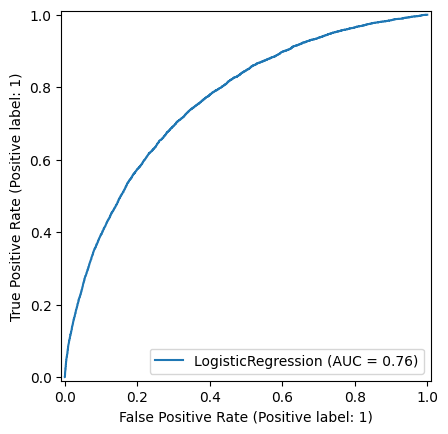

In [268]:
# import Roc curve function from the sklearn module
from sklearn.metrics import RocCurveDisplay

# plot AUC curve
RocCurveDisplay.from_estimator(model, x_valid_transformed, y_valid);

In [269]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# confusion matrix
print(confusion_matrix(y_valid, y_preds))

[[70537   135]
 [ 6048   158]]


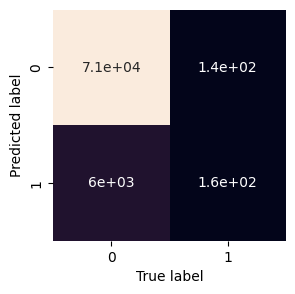

In [270]:
def plot_conf_mat(y_valid, y_preds):
  """
  Plots a nice looking confusion matrix
  using seaborn's heatmap()
  """
  fig, ax = plt.subplots(figsize=(3,3))
  ax = sns.heatmap(confusion_matrix(y_valid, y_preds),
                   annot=True,
                   cbar=False)
  plt.xlabel("True label")
  plt.ylabel("Predicted label")

plot_conf_mat(y_valid, y_preds)

The baseline Logistic Regression model is **very conservative about predicting class 1**.

It correctly identified only **90 out of 3,985 actual class-1 applicants**, while missing **3,895** of them.

So although our **ROC-AUC = 0.7581** indicates that the model has a useful ability to distinguish and rank applicants by their likelihood of repayment difficulties, the confusion matrix shows that its **default 0.5 threshold results in very few class-1 predictions**.

This means the model is good at ranking applicants, but at the default threshold, it is **missing many of the applicants we actually want to identify as class 1**.

That leads us naturally to **recall**, which will tell us how good the model is at actually finding the class-1 applicants.

Let's evaluate our baseline model.


In [271]:
def evaluate_preds(y_valid, y_preds):
  """
  Performs evaluation comparison on y_valid labels
  vs. y_pred labels on a classification
  """
  accuracy = accuracy_score(y_valid, y_preds)
  precision = precision_score(y_valid, y_preds)
  recall = recall_score(y_valid, y_preds)
  f1 = f1_score(y_valid, y_preds)

  metric_dict = {"Accuracy": round(accuracy, 2),
                 "Precision": round(precision, 2),
                 "Recall": round(recall, 2),
                 "F1": round(f1, 2)}

  return metric_dict

evaluate_preds(y_valid, y_preds)

{'Accuracy': 0.92, 'Precision': 0.54, 'Recall': 0.03, 'F1': 0.05}

The **92% accuracy is misleading** because the dataset is highly imbalanced toward class `0`.

The biggest problem is **recall = 2%**: at the default **0.5 threshold**, the model identifies only a very small proportion of the actual class-1 applicants and misses most of them.

The **precision = 54%** means that when the model does predict class `1`, about 54% of those predictions are actually class `1`.

The **F1 score = 4%** is very low because the model has extremely low recall, even though its precision is reasonably higher.

At the same time, **ROC-AUC = 0.7581** suggests that the model does have useful predictive/ranking ability.

**Therefore, our baseline model isn't simply "bad" — its current 0.5 decision threshold is causing it to predict class `1` very rarely.** We should investigate whether lowering the threshold can improve recall while maintaining an acceptable level of precision.


### Classification Threshold Analysis

In [272]:
y_probs = model.predict_proba(x_valid_transformed)[:, 1]

thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

for threshold in thresholds:
    y_preds = (y_probs >= threshold).astype(int)

    precision = precision_score(y_valid, y_preds)
    recall = recall_score(y_valid, y_preds)
    f1 = f1_score(y_valid, y_preds)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1:        {f1:.2f}")
    print()

Threshold: 0.5
Precision: 0.54
Recall:    0.03
F1:        0.05

Threshold: 0.4
Precision: 0.47
Recall:    0.06
F1:        0.11

Threshold: 0.3
Precision: 0.38
Recall:    0.14
F1:        0.20

Threshold: 0.2
Precision: 0.30
Recall:    0.29
F1:        0.29

Threshold: 0.1
Precision: 0.19
Recall:    0.60
F1:        0.29



The Logistic Regression model outputs a probability that an applicant belongs to class `1`. By default, a **0.5 classification threshold** is used: probabilities ≥ 0.5 are classified as class `1`, while probabilities below 0.5 are classified as class `0`.

Because the dataset is highly imbalanced, the 0.5 threshold produced very low **recall (2%)**, meaning the model detected very few of the actual class-1 applicants. Instead of immediately changing the model, I tested different thresholds to understand how the classification decision affects performance.

### Key Learning

Lowering the classification threshold causes the model to classify more applicants as class `1`. This generally increases **recall**, because more actual class-1 cases are detected, but decreases **precision**, because more false positives are introduced.

In this experiment, recall increased from **2% at a 0.50 threshold to 60% at 0.10**, while precision decreased from **54% to 19%**.

The **F1 score increased from 4% at 0.50 to 29% at 0.10**. Interestingly, the F1 score reached the same 29% at a threshold of 0.20, but the 0.10 threshold achieved much higher recall (60% compared with 29%).

| Threshold | Precision | Recall |  F1 |
| --------: | --------: | -----: | --: |
|      0.50 |       54% |     2% |  4% |
|      0.40 |       44% |     6% | 10% |
|      0.30 |       39% |    13% | 20% |
|      0.20 |       29% |    29% | 29% |
|      0.10 |       19% |    60% | 29% |

The important lesson is that the **classification threshold controls the trade-off between precision and recall**. The threshold is not part of the model's training; it is the decision rule applied to the model's predicted probabilities.

The threshold should therefore be chosen according to the practical objective and the relative cost of **false positives and false negatives**, rather than simply choosing the threshold that produces the highest score on the validation data.

For this project, where identifying applicants likely to experience repayment difficulties is important, a lower threshold may be more useful if **missing a true class-1 applicant is more costly than investigating a false positive**.


## Model Experimentation

We're going to try 3 different machine learning Models:
1. Random Forest Classifier — captures nonlinear relationships and interactions between features.
2. Gradient Boosting models — can capture more complex patterns in the data and are commonly effective for tabular datasets.
3. LightGBM / XGBoost — will be considered for further experimentation with the large, structured dataset.

In [273]:
# Put models in a dictionary
models = {
    "Random Forest Classifier": RandomForestClassifier(),
    "Gradient Boosting Model": GradientBoostingClassifier(),
    "LightGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier()
}

In [274]:
def fit_and_score(models, x_train_transformed, x_valid_transformed, y_train, y_valid):
    """
    Fits and evaluates given machine learning models using ROC-AUC.
    Includes progress messages so we can see which model is taking too long.
    """

    np.random.seed(42)

    model_scores = {}

    for name, model in models.items():

        print(f"\n{'='*50}")
        print(f"Starting: {name}")
        print(f"{'='*50}")

        # Fit model
        print("Fitting model...")
        model.fit(x_train_transformed, y_train)
        print("Model finished fitting!")

        # Get probability of class 1
        print("Making predictions...")
        y_pred_proba = model.predict_proba(x_valid_transformed)[:, 1]
        print("Predictions finished!")

        # Calculate ROC-AUC
        print("Calculating ROC-AUC...")
        model_scores[name] = roc_auc_score(y_valid, y_pred_proba)

        print(f"{name} ROC-AUC: {model_scores[name]:.4f}")

    return model_scores

In [275]:
model_scores = fit_and_score(models=models,
                             x_train_transformed=x_train_transformed,
                             x_valid_transformed=x_valid_transformed,
                             y_train=y_train,
                             y_valid=y_valid)
model_scores


Starting: Random Forest Classifier
Fitting model...
Model finished fitting!
Making predictions...
Predictions finished!
Calculating ROC-AUC...
Random Forest Classifier ROC-AUC: 0.7238

Starting: Gradient Boosting Model
Fitting model...
Model finished fitting!
Making predictions...
Predictions finished!
Calculating ROC-AUC...
Gradient Boosting Model ROC-AUC: 0.7672

Starting: LightGBM
Fitting model...
[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.356142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18134
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 280
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470
Model finished fitting!
Making pr

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Predictions finished!
Calculating ROC-AUC...
LightGBM ROC-AUC: 0.7725

Starting: XGBoost
Fitting model...
Model finished fitting!
Making predictions...
Predictions finished!
Calculating ROC-AUC...
XGBoost ROC-AUC: 0.7641


{'Random Forest Classifier': np.float64(0.7238201003436391),
 'Gradient Boosting Model': np.float64(0.7672282508889752),
 'LightGBM': np.float64(0.7725217498588752),
 'XGBoost': np.float64(0.764053456369062)}

### Model Experimentation

After establishing our Logistic Regression baseline, I tested four tree-based classification models: Random Forest, Gradient Boosting, LightGBM, and XGBoost.

Since the dataset is highly imbalanced, **ROC-AUC** is used to compare the models rather than accuracy. ROC-AUC measures how well a model can distinguish between class `0` and class `1` across different classification thresholds.

The results were:

| Model                    |    ROC-AUC |
| ------------------------ | ---------: |
| Random Forest Classifier |     0.7188 |
| Gradient Boosting Model  |     0.7632 |
| LightGBM                 | **0.7648** |
| XGBoost                  |     0.7513 |

**LightGBM achieved the highest ROC-AUC of 0.7648**, followed closely by Gradient Boosting with 0.7632. XGBoost achieved 0.7513, while Random Forest had the lowest score at 0.7188.

This suggests that **LightGBM is currently the strongest candidate among the models tested**, although its advantage over Gradient Boosting is very small.

Therefore, LightGBM and Gradient Boosting are the most promising models to investigate further. The next step is to examine their performance in more detail and tune the hyperparameters of the most promising model.


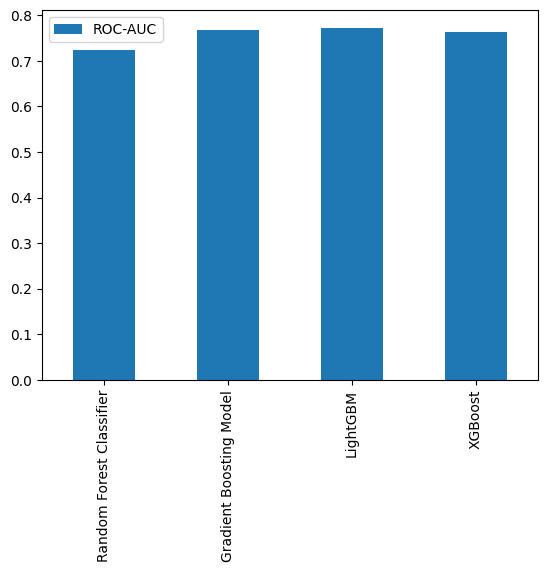

In [276]:
# Model comparison
model_compare = pd.DataFrame(model_scores, index=["ROC-AUC"])

model_compare.T.plot.bar();

# 10. Hyperparameter Tuning — LightGBM

Our baseline LightGBM achieved a ROC-AUC of approximately **0.7725**.


In [277]:
%%time

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# Store results from each experiment
lgbm_results = {}

# Baseline configuration
lgbm_baseline = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=2
)

lgbm_baseline.fit(
    x_train_transformed,
    y_train
)

baseline_pred = lgbm_baseline.predict_proba(
    x_valid_transformed
)[:, 1]

lgbm_results["Baseline"] = roc_auc_score(
    y_valid,
    baseline_pred
)

print(f"Baseline ROC-AUC: {lgbm_results['Baseline']:.4f}")

[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.610145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18160
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 280
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Baseline ROC-AUC: 0.7725
CPU times: user 37.8 s, sys: 869 ms, total: 38.7 s
Wall time: 24.8 s


### Experiment 1 — Increase the number of trees

In [278]:
%%time

lgbm_1 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    n_jobs=2
)

lgbm_1.fit(
    x_train_transformed,
    y_train
)

pred_1 = lgbm_1.predict_proba(
    x_valid_transformed
)[:, 1]

lgbm_results["More Trees"] = roc_auc_score(
    y_valid,
    pred_1
)

print(f"More Trees ROC-AUC: {lgbm_results['More Trees']:.4f}")

[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.492502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18160
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 280
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


More Trees ROC-AUC: 0.7716
CPU times: user 1min 13s, sys: 1.1 s, total: 1min 14s
Wall time: 47.7 s


### Experiment 2 — Reduce the learning rate

In [279]:
%%time

lgbm_2 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=2
)

lgbm_2.fit(
    x_train_transformed,
    y_train
)

pred_2 = lgbm_2.predict_proba(
    x_valid_transformed
)[:, 1]

lgbm_results["Lower Learning Rate"] = roc_auc_score(
    y_valid,
    pred_2
)

print(f"Lower Learning Rate ROC-AUC: {lgbm_results['Lower Learning Rate']:.4f}")


[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.495147 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18160
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 280
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Lower Learning Rate ROC-AUC: 0.7745
CPU times: user 1min 24s, sys: 1.33 s, total: 1min 26s
Wall time: 53.7 s


### Experiment 3 — Increase tree complexity

In [280]:
%%time

lgbm_3 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=50,
    random_state=42,
    n_jobs=2
)

lgbm_3.fit(
    x_train_transformed,
    y_train
)

pred_3 = lgbm_3.predict_proba(
    x_valid_transformed
)[:, 1]

lgbm_results["More Leaves"] = roc_auc_score(
    y_valid,
    pred_3
)

print(f"More Leaves ROC-AUC: {lgbm_results['More Leaves']:.4f}")


[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.531822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 18160
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 280
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


More Leaves ROC-AUC: 0.7746
CPU times: user 1min 37s, sys: 1.29 s, total: 1min 38s
Wall time: 1min


### Experiment 4 — Increase minimum child samples

In [281]:
%%time

lgbm_4 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    random_state=42,
    n_jobs=2
)

lgbm_4.fit(
    x_train_transformed,
    y_train
)

pred_4 = lgbm_4.predict_proba(
    x_valid_transformed
)[:, 1]

lgbm_results["More Child Samples"] = roc_auc_score(
    y_valid,
    pred_4
)

print(f"More Child Samples ROC-AUC: {lgbm_results['More Child Samples']:.4f}")


[LightGBM] [Info] Number of positive: 18619, number of negative: 212014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.293789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 18136
[LightGBM] [Info] Number of data points in the train set: 230633, number of used features: 270
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432470
[LightGBM] [Info] Start training from score -2.432470


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


More Child Samples ROC-AUC: 0.7754
CPU times: user 1min 25s, sys: 1.29 s, total: 1min 26s
Wall time: 54.4 s


### Compare the experiments

In [282]:
lgbm_results

{'Baseline': np.float64(0.7724648174723521),
 'More Trees': np.float64(0.7716427657956753),
 'Lower Learning Rate': np.float64(0.774545763460704),
 'More Leaves': np.float64(0.7745666850297364),
 'More Child Samples': np.float64(0.7754010807969474)}

In [283]:

lgbm_compare = pd.DataFrame(
    lgbm_results,
    index=["ROC-AUC"]
)

In [284]:
lgbm_compare.T.sort_values(
    by="ROC-AUC",
    ascending=False
)

,ROC-AUC
More Child Samples,0.775401
More Leaves,0.774567
Lower Learning Rate,0.774546
Baseline,0.772465
More Trees,0.771643


In [285]:
best_lgbm_experiment = max(
    lgbm_results,
    key=lgbm_results.get
)

print("Best experiment:", best_lgbm_experiment)
print("Best ROC-AUC:", lgbm_results[best_lgbm_experiment])

Best experiment: More Child Samples
Best ROC-AUC: 0.7754010807969474


### Experiment 5: Increase minimum child samples to 200

In [286]:
%%time

lgbm_5 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=200,  # Increased from 100 to 200
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

lgbm_5.fit(
    x_train_transformed,
    y_train
)

pred_5 = lgbm_5.predict_proba(
    x_valid_transformed
)[:, 1]

lgbm_results["Child Samples 200"] = roc_auc_score(
    y_valid,
    pred_5
)

print(f"Child Samples 200 ROC-AUC: " f"{lgbm_results['Child Samples 200']:.6f}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Child Samples 200 ROC-AUC: 0.775399
CPU times: user 1min 21s, sys: 1.3 s, total: 1min 22s
Wall time: 51.9 s


In [287]:
lgbm_comparison = pd.DataFrame(
    list(lgbm_results.items()),
    columns=["Experiment", "ROC-AUC"]
).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

lgbm_comparison

,Experiment,ROC-AUC
0,More Child Samples,0.775401
1,Child Samples 200,0.775399
2,More Leaves,0.774567
3,Lower Learning Rate,0.774546
4,Baseline,0.772465
5,More Trees,0.771643


### Early stopping

In [288]:
%%time

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score

lgbm_early = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,
    random_state=42,
    n_jobs=2,
    verbosity=-1
)

lgbm_early.fit(
    x_train_transformed,
    y_train,
    eval_set=[(x_valid_transformed, y_valid)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50)
    ]
)

early_pred = lgbm_early.predict_proba(
    x_valid_transformed
)[:, 1]

early_auc = roc_auc_score(y_valid, early_pred)

print(f"Early stopping ROC-AUC: {early_auc:.6f}")
print(f"Best iteration: {lgbm_early.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.758534	valid_0's binary_logloss: 0.247468
[100]	valid_0's auc: 0.768909	valid_0's binary_logloss: 0.242839
[150]	valid_0's auc: 0.773005	valid_0's binary_logloss: 0.241236
[200]	valid_0's auc: 0.77439	valid_0's binary_logloss: 0.240685
[250]	valid_0's auc: 0.774985	valid_0's binary_logloss: 0.240456
[300]	valid_0's auc: 0.775401	valid_0's binary_logloss: 0.24032
[350]	valid_0's auc: 0.775632	valid_0's binary_logloss: 0.240255
[400]	valid_0's auc: 0.775817	valid_0's binary_logloss: 0.240179
[450]	valid_0's auc: 0.776191	valid_0's binary_logloss: 0.240081
[500]	valid_0's auc: 0.776136	valid_0's binary_logloss: 0.240087
Early stopping, best iteration is:
[462]	valid_0's auc: 0.776293	valid_0's binary_logloss: 0.240044


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Early stopping ROC-AUC: 0.776293
Best iteration: 462
CPU times: user 2min 20s, sys: 1.74 s, total: 2min 22s
Wall time: 1min 28s


# 12. Final LightGBM Model

In [289]:
# Our best model was found using early stopping
final_lgbm = lgbm_early

print("Final LightGBM model selected.")
print(f"Number of trees: {final_lgbm.best_iteration_}")
print(f"Learning rate: {final_lgbm.learning_rate}")
print(f"Number of leaves: {final_lgbm.num_leaves}")
print(f"Minimum child samples: {final_lgbm.min_child_samples}")

Final LightGBM model selected.
Number of trees: 462
Learning rate: 0.05
Number of leaves: 31
Minimum child samples: 100


In [290]:
# Generate final validation probability predictions

final_valid_proba = final_lgbm.predict_proba(
    x_valid_transformed
)[:, 1]

print(final_valid_proba[:10])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0.31105534 0.03921132 0.06696056 0.02351286 0.2914147  0.03795
 0.01789569 0.02190854 0.04524378 0.02512712]


In [291]:
final_auc = roc_auc_score(
    y_valid,
    final_valid_proba
)

print(f"Final LightGBM ROC-AUC: {final_auc:.6f}")

Final LightGBM ROC-AUC: 0.776293


## Evaluating the tuned LightGM Model

In [293]:
# Probability of TARGET = 1
final_valid_proba = final_lgbm.predict_proba(x_valid_transformed)[:, 1]

# Convert probabilities into class predictions
final_valid_preds = (final_valid_proba >= 0.5).astype(int)

# Look at the first few predictions
print(final_valid_preds[:100])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [294]:
# Evaluate the tuned LightGBM using a 0.5 threshold

final_metrics = evaluate_preds(
    y_valid,
    final_valid_preds)

final_metrics

{'Accuracy': 0.92, 'Precision': 0.6, 'Recall': 0.04, 'F1': 0.08}

In [295]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_valid,
    final_valid_preds)


print(cm)

[[70499   173]
 [ 5942   264]]


- TN = 70,499
- FP = 173
- FN = 5,942
- TP = 264

For Home Credit:

- TN → correctly predicted no repayment difficulty
- FP → predicted difficulty, but applicant didn't have difficulty
- FN → predicted no difficulty, but applicant actually had difficulty
- TP → correctly predicted repayment difficulty

The **FN** category is particularly important from a credit-risk perspective because these are applicants the model thought were relatively safe but who actually experienced repayment difficulties.

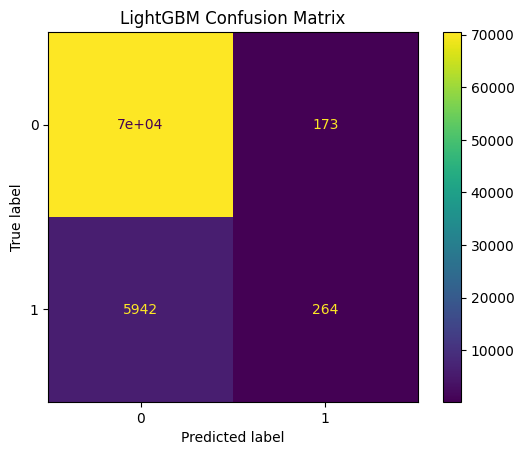

In [296]:
# We can also display it visually:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.title("LightGBM Confusion Matrix")
plt.show()

In [297]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(y_valid, final_valid_preds))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     70672
           1       0.60      0.04      0.08      6206

    accuracy                           0.92     76878
   macro avg       0.76      0.52      0.52     76878
weighted avg       0.90      0.92      0.89     76878



## Threshold Analysis

The LightGBM model outputs a probability between 0 and 1 indicating how likely an applicant is to experience repayment difficulties (`TARGET = 1`).

By default, a threshold of `0.5` is used to convert probabilities into class predictions:

- Probability >= 0.5 → `TARGET = 1`
- Probability < 0.5 → `TARGET = 0`

However, the dataset is imbalanced, with significantly more applicants in `TARGET = 0` than `TARGET = 1`. Therefore, accuracy alone is not a suitable metric for selecting the classification threshold.


At the default threshold, the model achieved:

- Accuracy: **0.92**
- Precision: **0.60**
- Recall: **0.04**
- F1: **0.08**

### Testing Different Thresholds

In [298]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    preds = (final_valid_proba >= threshold).astype(int)

    metrics = evaluate_preds(y_valid, preds)

    print(f"Threshold: {threshold}")
    print(metrics)
    print()

Threshold: 0.1
{'Accuracy': 0.77, 'Precision': 0.2, 'Recall': 0.62, 'F1': 0.31}

Threshold: 0.2
{'Accuracy': 0.89, 'Precision': 0.3, 'Recall': 0.33, 'F1': 0.32}

Threshold: 0.3
{'Accuracy': 0.91, 'Precision': 0.4, 'Recall': 0.18, 'F1': 0.25}

Threshold: 0.4
{'Accuracy': 0.92, 'Precision': 0.49, 'Recall': 0.09, 'F1': 0.16}

Threshold: 0.5
{'Accuracy': 0.92, 'Precision': 0.6, 'Recall': 0.04, 'F1': 0.08}



To investigate the precision-recall trade-off, several thresholds were tested using the validation-set probabilities.

| Threshold | Accuracy | Precision | Recall | F1 |
|-----------|----------|-----------|--------|-----|
| 0.10 | 0.77 | 0.20 | 0.62 | 0.31 |
| 0.20 | 0.89 | 0.30 | 0.33 | 0.32 |
| 0.30 | 0.91 | 0.40 | 0.18 | 0.25 |
| 0.40 | 0.92 | 0.49 | 0.09 | 0.16 |
| 0.50 | 0.92 | 0.60 | 0.04 | 0.08 |

As the threshold decreases, the model becomes more willing to classify applicants as `TARGET = 1`.

This increases recall but generally decreases precision.

### Fine-Grained Threshold Search


In [299]:
import numpy as np

thresholds = np.arange(0.05, 0.51, 0.01)

best_threshold = 0
best_f1 = 0

for threshold in thresholds:
    preds = (final_valid_proba >= threshold).astype(int)

    metrics = evaluate_preds(y_valid, preds)

    if metrics["F1"] > best_f1:
        best_f1 = metrics["F1"]
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 0.14
Best F1: 0.33


Rather than testing only a few thresholds, thresholds from `0.05` to `0.50` were evaluated in increments of `0.01`.

The threshold producing the highest validation F1 score was:

```text
Best threshold: 0.14
Best F1: 0.33

The default `0.50` threshold was not appropriate for this imbalanced credit-risk problem. Fine-grained threshold analysis found `0.14` to provide the highest validation F1 score of `0.33`.

## Generate predictions on `application_test.csv`

In [365]:
test_df = pd.read_csv("/content/application_test.csv")
test_df

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,1.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0


In [366]:
df_features.shape, test_df.shape

((307511, 162), (48744, 121))

In [367]:
print("Training columns:", len(x.columns))
print("Test columns:", len(test_df.columns))

missing_from_test = set(x.columns) - set(test_df.columns)

print("Features in training but missing from test:")
print(missing_from_test)

Training columns: 161
Test columns: 121
Features in training but missing from test:
{'phone_change_years', 'bureau_total_credit_sum', 'bureau_overdue_credit_count', 'cc_max_dpd_def', 'previous_approved_count', 'installments_payment_count', 'cc_max_utilization', 'installments_late_count', 'income_per_person', 'previous_approval_rate', 'annuity_income_ratio', 'age_years', 'id_publish_years', 'previous_application_count', 'cc_dpd_count', 'avg_late_days', 'employment_missing', 'registration_years', 'bureau_max_days_overdue', 'credit_goods_ratio', 'cc_dpd_def_count', 'log_avg_late_days', 'bureau_problem_credit_count', 'previous_refused_count', 'credit_income_ratio', 'cc_avg_utilization', 'cc_payment_count', 'cc_avg_payment', 'total_bureau_problem_months', 'bureau_credit_count', 'bureau_total_debt', 'pos_max_dpd_def', 'employment_years', 'pos_dpd_def_count', 'cc_max_dpd', 'max_late_days', 'bureau_active_credit_count', 'pos_dpd_count', 'installments_late_rate', 'pos_max_dpd'}


**Application features**

In [368]:
# Copy test application data
test_features = test_df.copy()

# Application-level features
test_features["annuity_income_ratio"] = (
    test_features["AMT_ANNUITY"] / test_features["AMT_INCOME_TOTAL"]
)

test_features["credit_income_ratio"] = (
    test_features["AMT_CREDIT"] / test_features["AMT_INCOME_TOTAL"]
)

test_features["credit_goods_ratio"] = (
    test_features["AMT_CREDIT"] / test_features["AMT_GOODS_PRICE"]
)

test_features["age_years"] = (
    -test_features["DAYS_BIRTH"] / 365
)

# Employment special value
test_features["employment_missing"] = (
    test_features["DAYS_EMPLOYED"] == 365243
).astype(int)

test_features["DAYS_EMPLOYED"] = (
    test_features["DAYS_EMPLOYED"].replace(365243, np.nan)
)

test_features["employment_years"] = (
    -test_features["DAYS_EMPLOYED"] / 365
)

test_features["registration_years"] = (
    -test_features["DAYS_REGISTRATION"] / 365
)

test_features["id_publish_years"] = (
    -test_features["DAYS_ID_PUBLISH"] / 365
)

test_features["phone_change_years"] = (
    -test_features["DAYS_LAST_PHONE_CHANGE"] / 365
)

test_features["income_per_person"] = (
    test_features["AMT_INCOME_TOTAL"] / test_features["CNT_FAM_MEMBERS"]
)

print(test_features.shape)

(48744, 131)


**Bureau features**

In [369]:
test_ids = set(test_features["SK_ID_CURR"])

bureau_test = bureau[
    bureau["SK_ID_CURR"].isin(test_ids)
].copy()

print(bureau_test.shape)

(251103, 17)


In [370]:
bureau_features = (
    bureau_test
    .groupby("SK_ID_CURR")
    .agg(
        bureau_credit_count=("SK_ID_BUREAU", "count"),

        bureau_max_days_overdue=(
            "CREDIT_DAY_OVERDUE",
            "max"
        ),

        bureau_active_credit_count=(
            "CREDIT_ACTIVE",
            lambda x: (x == "Active").sum()
        ),

        bureau_total_credit_sum=(
            "AMT_CREDIT_SUM",
            "sum"
        ),

        bureau_total_debt=(
            "AMT_CREDIT_SUM_DEBT",
            "sum"
        ),

        bureau_overdue_credit_count=(
            "CREDIT_DAY_OVERDUE",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

In [371]:
test_features = test_features.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

In [372]:
bureau_cols = [
    "bureau_credit_count",
    "bureau_overdue_credit_count",
    "bureau_max_days_overdue",
    "bureau_active_credit_count",
    "bureau_total_credit_sum",
    "bureau_total_debt"
]

test_features[bureau_cols] = (
    test_features[bureau_cols].fillna(0)
)

**Bureau balance features**

In [373]:
bureau_balance_test = bureau_balance[
    bureau_balance["SK_ID_BUREAU"].isin(
        bureau_test["SK_ID_BUREAU"]
    )
].copy()

In [374]:
bureau_balance_test["status_problem"] = (
    bureau_balance_test["STATUS"]
    .isin(["1", "2", "3", "4", "5"])
    .astype(int)
)

In [375]:
bureau_problem_months = (
    bureau_balance_test
    .groupby("SK_ID_BUREAU")["status_problem"]
    .sum()
    .reset_index(name="bureau_problem_months")
)

In [376]:
bureau_problem_months = bureau_problem_months.merge(
    bureau_test[["SK_ID_BUREAU", "SK_ID_CURR"]],
    on="SK_ID_BUREAU",
    how="left"
)

In [377]:
applicant_problem_months = (
    bureau_problem_months
    .groupby("SK_ID_CURR")["bureau_problem_months"]
    .sum()
    .reset_index(name="total_bureau_problem_months")
)

bureau_problem_months["had_problem"] = (
    bureau_problem_months["bureau_problem_months"] > 0
).astype(int)

applicant_problem_credit_count = (
    bureau_problem_months
    .groupby("SK_ID_CURR")["had_problem"]
    .sum()
    .reset_index(name="bureau_problem_credit_count")
)

In [378]:
test_features = test_features.merge(
    applicant_problem_months,
    on="SK_ID_CURR",
    how="left"
)

test_features = test_features.merge(
    applicant_problem_credit_count,
    on="SK_ID_CURR",
    how="left"
)

test_features[
    [
        "total_bureau_problem_months",
        "bureau_problem_credit_count"
    ]
] = test_features[
    [
        "total_bureau_problem_months",
        "bureau_problem_credit_count"
    ]
].fillna(0)

**Previous applications**

In [379]:
previous_application_test = previous_application[
    previous_application["SK_ID_CURR"].isin(test_ids)
].copy()

previous_application_count_test = (
    previous_application_test
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="previous_application_count")
)

previous_approved_count_test = (
    previous_application_test[
        previous_application_test["NAME_CONTRACT_STATUS"] == "Approved"
    ]
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="previous_approved_count")
)

previous_refused_count_test = (
    previous_application_test[
        previous_application_test["NAME_CONTRACT_STATUS"] == "Refused"
    ]
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="previous_refused_count")
)

previous_app_features_test = (
    previous_application_count_test
    .merge(
        previous_approved_count_test,
        on="SK_ID_CURR",
        how="left"
    )
)

previous_app_features_test["previous_approved_count"] = (
    previous_app_features_test["previous_approved_count"].fillna(0)
)

previous_app_features_test["previous_approval_rate"] = (
    previous_app_features_test["previous_approved_count"]
    / previous_app_features_test["previous_application_count"]
)

previous_app_features_test = (
    previous_app_features_test
    .merge(
        previous_refused_count_test,
        on="SK_ID_CURR",
        how="left"
    )
)

previous_app_features_test["previous_refused_count"] = (
    previous_app_features_test["previous_refused_count"].fillna(0)
)

test_features = test_features.merge(
    previous_app_features_test,
    on="SK_ID_CURR",
    how="left"
)

previous_app_cols = [
    "previous_application_count",
    "previous_approved_count",
    "previous_approval_rate",
    "previous_refused_count"
]

test_features[previous_app_cols] = (
    test_features[previous_app_cols].fillna(0)
)

print(test_features.shape)

(48744, 143)


**Installment features**

In [380]:
# Keep only installment records belonging to test applicants
installments_test = installments_payments[
    installments_payments["SK_ID_CURR"].isin(test_ids)
].copy()

print(installments_test.shape)

(2013809, 11)


In [381]:
# -----------------------------
# Installment payment delay
# -----------------------------

installments_test["payment_delay_days"] = (
    installments_test["DAYS_ENTRY_PAYMENT"]
    - installments_test["DAYS_INSTALMENT"]
)

# 1 = paid late
# 0 = paid on time
installments_test["paid_late"] = (
    installments_test["payment_delay_days"] > 0
).astype(int)

In [382]:
installments_late_count_test = (
    installments_test
    .groupby("SK_ID_CURR")["paid_late"]
    .sum()
    .reset_index(name="installments_late_count")
)

In [383]:
installments_payment_count_test = (
    installments_test
    .groupby("SK_ID_CURR")["SK_ID_PREV"]
    .count()
    .reset_index(name="installments_payment_count")
)

In [384]:
installments_features_test = (
    installments_late_count_test
    .merge(
        installments_payment_count_test,
        on="SK_ID_CURR",
        how="left"
    )
)

installments_features_test["installments_late_rate"] = (
    installments_features_test["installments_late_count"]
    / installments_features_test["installments_payment_count"]
)

In [385]:
installments_test["late_days"] = (
    installments_test["payment_delay_days"]
    .where(
        installments_test["payment_delay_days"] > 0,
        0
    )
)

In [386]:
avg_late_days_test = (
    installments_test[
        installments_test["late_days"] > 0
    ]
    .groupby("SK_ID_CURR")["late_days"]
    .mean()
    .reset_index(name="avg_late_days")
)

In [387]:
max_late_days_test = (
    installments_test[
        installments_test["late_days"] > 0
    ]
    .groupby("SK_ID_CURR")["late_days"]
    .max()
    .reset_index(name="max_late_days")
)

In [388]:
installments_features_test = (
    installments_features_test
    .merge(
        avg_late_days_test,
        on="SK_ID_CURR",
        how="left"
    )
    .merge(
        max_late_days_test,
        on="SK_ID_CURR",
        how="left"
    )
)

In [389]:
test_features = test_features.merge(
    installments_features_test,
    on="SK_ID_CURR",
    how="left"
)

In [390]:
installments_cols = [
    "installments_payment_count",
    "installments_late_count",
    "installments_late_rate",
    "avg_late_days",
    "max_late_days"
]

test_features[installments_cols] = (
    test_features[installments_cols]
    .fillna(0)
)

In [391]:
print(test_features.shape)

print(
    test_features[installments_cols]
    .isna()
    .sum()
)

(48744, 148)
installments_payment_count    0
installments_late_count       0
installments_late_rate        0
avg_late_days                 0
max_late_days                 0
dtype: int64


**POS/CASH features**

In [392]:
# Keep only POS/CASH records for test applicants
POS_CASH_test = POS_CASH_balance[
    POS_CASH_balance["SK_ID_CURR"].isin(test_ids)
].copy()

print(POS_CASH_test.shape)

(1457983, 10)


In [393]:
# 1 = DPD occurred
# 0 = no DPD
POS_CASH_test["pos_dpd_flag"] = (
    POS_CASH_test["SK_DPD"] > 0
).astype(int)

# 1 = DPD_DEF occurred
# 0 = no DPD_DEF
POS_CASH_test["pos_dpd_def_flag"] = (
    POS_CASH_test["SK_DPD_DEF"] > 0
).astype(int)

In [394]:
pos_features_test = (
    POS_CASH_test
    .groupby("SK_ID_CURR")
    .agg(
        pos_dpd_count=("pos_dpd_flag", "sum"),

        pos_max_dpd=("SK_DPD", "max"),

        pos_dpd_def_count=("pos_dpd_def_flag", "sum"),

        pos_max_dpd_def=("SK_DPD_DEF", "max")
    )
    .reset_index()
)

In [395]:
test_features = test_features.merge(
    pos_features_test,
    on="SK_ID_CURR",
    how="left"
)

In [396]:
pos_cols = [
    "pos_dpd_count",
    "pos_max_dpd",
    "pos_dpd_def_count",
    "pos_max_dpd_def"
]

test_features[pos_cols] = (
    test_features[pos_cols]
    .fillna(0)
)

In [397]:
print(test_features.shape)

print(
    test_features[pos_cols]
    .isna()
    .sum()
)

(48744, 152)
pos_dpd_count        0
pos_max_dpd          0
pos_dpd_def_count    0
pos_max_dpd_def      0
dtype: int64


**Credit-card features**

In [398]:
credit_card_test = credit_card_balance[
    credit_card_balance["SK_ID_CURR"].isin(test_ids)
].copy()

print(credit_card_test.shape)

(612347, 27)


In [399]:
credit_card_test["cc_utilization"] = np.where(
    (credit_card_test["AMT_CREDIT_LIMIT_ACTUAL"] > 0) &
    (credit_card_test["AMT_BALANCE"] >= 0),

    credit_card_test["AMT_BALANCE"] /
    credit_card_test["AMT_CREDIT_LIMIT_ACTUAL"],

    np.nan
)

In [400]:
credit_card_test["cc_payment_made"] = (
    credit_card_test["AMT_PAYMENT_TOTAL_CURRENT"] > 0
).astype(int)

In [401]:
credit_card_test["cc_dpd"] = (
    credit_card_test["SK_DPD"] > 0
).astype(int)

credit_card_test["cc_dpd_def"] = (
    credit_card_test["SK_DPD_DEF"] > 0
).astype(int)

In [402]:
cc_features_test = (
    credit_card_test
    .groupby("SK_ID_CURR")
    .agg(

        cc_dpd_count=("cc_dpd", "sum"),

        cc_max_dpd=("SK_DPD", "max"),

        cc_dpd_def_count=("cc_dpd_def", "sum"),

        cc_max_dpd_def=("SK_DPD_DEF", "max"),

        cc_avg_utilization=("cc_utilization", "mean"),

        cc_max_utilization=("cc_utilization", "max"),

        cc_payment_count=("cc_payment_made", "sum"),

        cc_avg_payment=("AMT_PAYMENT_TOTAL_CURRENT", "mean")
    )
    .reset_index()
)

In [403]:
print(cc_features_test.shape)
print(cc_features_test.head())
print(cc_features_test.isna().sum())

(16653, 9)
   SK_ID_CURR  cc_dpd_count  cc_max_dpd  cc_dpd_def_count  cc_max_dpd_def  \
0      100013             1           1                 1               1   
1      100028             0           0                 0               0   
2      100042             2           1                 0               0   
3      100066             0           0                 0               0   
4      100067             3           1                 3               1   

   cc_avg_utilization  cc_max_utilization  cc_payment_count  cc_avg_payment  
0            0.115301            1.024890                15     6817.172344  
1            0.035934            0.165937                41     5606.152347  
2            0.370624            1.034649                37     7369.821429  
3            0.000000            0.000000                 0        0.000000  
4            0.604061            1.057380                61     3688.862069  
SK_ID_CURR              0
cc_dpd_count            0
cc_max

In [404]:
test_features = test_features.merge(
    cc_features_test,
    on="SK_ID_CURR",
    how="left"
)

In [405]:
cc_cols = [
    "cc_dpd_count",
    "cc_max_dpd",
    "cc_dpd_def_count",
    "cc_max_dpd_def",
    "cc_avg_utilization",
    "cc_max_utilization",
    "cc_payment_count",
    "cc_avg_payment"
]

test_features[cc_cols] = (
    test_features[cc_cols]
    .fillna(0)
)

In [406]:
print(test_features.shape)

print(
    test_features[cc_cols]
    .isna()
    .sum()
)

(48744, 160)
cc_dpd_count          0
cc_max_dpd            0
cc_dpd_def_count      0
cc_max_dpd_def        0
cc_avg_utilization    0
cc_max_utilization    0
cc_payment_count      0
cc_avg_payment        0
dtype: int64


**compare your test columns against the exact columns used to train LightGBM:**

In [407]:
missing = set(x.columns) - set(test_features.columns)

extra = set(test_features.columns) - set(x.columns)

print("Missing:", missing)
print("Extra:", extra)
print("Test shape:", test_features.shape)
print("Training X shape:", x.shape)

Missing: {'log_avg_late_days'}
Extra: set()
Test shape: (48744, 160)
Training X shape: (307511, 161)


In [408]:
# Create the same feature that existed in training
test_features["log_avg_late_days"] = np.log1p(test_features["avg_late_days"])

print(test_features["log_avg_late_days"].head())

0    2.484907
1    0.693147
2    2.155982
3    1.252763
4    0.000000
Name: log_avg_late_days, dtype: float64


In [409]:
# check the columns again
missing = set(x.columns) - set(test_features.columns)
extra = set(test_features.columns) - set(x.columns)

print("Missing:", missing)
print("Extra:", extra)
print("Test shape:", test_features.shape)
print("Training X shape:", x.shape)

Missing: set()
Extra: set()
Test shape: (48744, 161)
Training X shape: (307511, 161)


In [412]:
# Put the columns in exactly the training order
test_x = test_features[x.columns]

print(test_x.shape)

(48744, 161)


**Use the existing preprocessor**

In [413]:
test_x_transformed = preprocessor.transform(test_x)

print(test_x_transformed.shape)

(48744, 291)


In [414]:
# Predict the test probabilities
test_proba = final_lgbm.predict_proba(test_x_transformed)[:, 1]

print(test_proba[:10])
print("Minimum:", test_proba.min())
print("Maximum:", test_proba.max())
print("Mean:", test_proba.mean())

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[0.04071711 0.1587473  0.01963013 0.02532947 0.09643022 0.06050217
 0.01517976 0.03790581 0.00798765 0.09443691]
Minimum: 0.003407657510001791
Maximum: 0.7594905151296196
Mean: 0.07078202857723137


In [415]:
# Now we create the Kaggle submission
submission = pd.DataFrame({
    "SK_ID_CURR": test_features["SK_ID_CURR"],
    "TARGET": test_proba})

print(submission.head())

   SK_ID_CURR    TARGET
0      100001  0.040717
1      100005  0.158747
2      100013  0.019630
3      100028  0.025329
4      100038  0.096430


In [416]:
print(submission.shape)

(48744, 2)


In [417]:
# Then save the prediction data
submission.to_csv("/content/home_credit_submission.csv", index=False)

print("Submission saved!")

Submission saved!


# 13. Feature Importance

Feature importance seeks to figure out which different attributes of the data were most importance when it comes to predicting the `TARGET` Variable.

In [418]:
# Get the feature names
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names[:20])

Number of features: 291
['cat__NAME_CONTRACT_TYPE_Cash loans'
 'cat__NAME_CONTRACT_TYPE_Revolving loans' 'cat__CODE_GENDER_F'
 'cat__CODE_GENDER_M' 'cat__CODE_GENDER_XNA' 'cat__FLAG_OWN_CAR_N'
 'cat__FLAG_OWN_CAR_Y' 'cat__FLAG_OWN_REALTY_N' 'cat__FLAG_OWN_REALTY_Y'
 'cat__NAME_TYPE_SUITE_Children' 'cat__NAME_TYPE_SUITE_Family'
 'cat__NAME_TYPE_SUITE_Group of people' 'cat__NAME_TYPE_SUITE_Other_A'
 'cat__NAME_TYPE_SUITE_Other_B' 'cat__NAME_TYPE_SUITE_Spouse, partner'
 'cat__NAME_TYPE_SUITE_Unaccompanied' 'cat__NAME_TYPE_SUITE_missing'
 'cat__NAME_INCOME_TYPE_Businessman'
 'cat__NAME_INCOME_TYPE_Commercial associate'
 'cat__NAME_INCOME_TYPE_Maternity leave']


In [420]:
# Get LightGBM feature importance
importance = final_lgbm.feature_importances_

print("Number of importance values:", len(importance))

Number of importance values: 291


In [421]:
gain_importance = final_lgbm.booster_.feature_importance(
    importance_type="gain"
)

feature_importance_gain = pd.DataFrame({
    "feature": feature_names,
    "importance": gain_importance
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance_gain.head(20)

,feature,importance
175,num__EXT_SOURCE_2,54253.410208
176,num__EXT_SOURCE_3,52743.549162
174,num__EXT_SOURCE_1,17471.993796
253,num__credit_goods_ratio,9575.836296
275,num__installments_late_rate,8669.359967
265,num__bureau_total_credit_sum,7566.583829
150,num__AMT_ANNUITY,6032.860496
274,num__installments_payment_count,5774.047143
287,num__cc_avg_utilization,5565.018242
153,num__DAYS_BIRTH,5546.421343


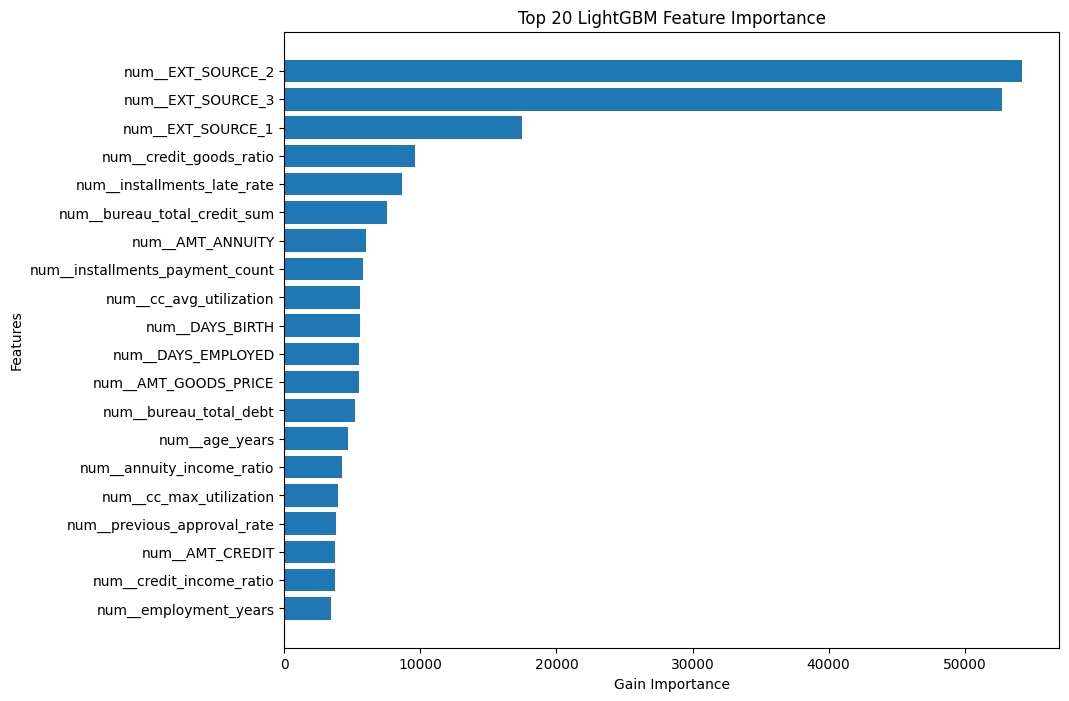

In [422]:
# plot the feature importance

# Get the top 20 most important features
top_features = feature_importance_gain.head(20)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

# Put the most important feature at the top
plt.gca().invert_yaxis()

plt.xlabel("Gain Importance")
plt.ylabel("Features")
plt.title("Top 20 LightGBM Feature Importance")

plt.show()